# AFC Lab — Fatigue Detection v8.2-SE+SWA (Stress Profile + FiLM + R-Drop + SWA)

**Версия 8.2 (revision SE+SWA)** — PhysioNet (Empatica E4, запястье): Exercise-only + Subject Stress Profile

## Анализ предыдущих экспериментов

| Версия | Ключевая идея | Test F1 | Поведение |
|---|---|---|---|
| v7.0 | baseline (no profile) | 0.801 | OK |
| v8.1 | profile concat (12K params) | **0.826** | OK |
| v8.2 large | enc=32, kernels=[12,9,6,4], drops=0.4-0.5 | — | полный overfit |
| v8.2 anti-overfit | enc=20, wd=5e-2 | 0.82 | потолок не пробит |

**Диагноз:** при ОЧЕНЬ разных конфигурациях (12K↔70K params) F1 упирается в потолок ~0.82. Это **архитектурный**, а не гиперпараметрический потолок.

## Что меняется в этой ревизии (анти-плато)

1. **SE-блоки** (Squeeze-and-Excitation) — channel attention внутри IMU энкодера. Канал-зависимое перевзвешивание после conv2 и conv3
2. **Иерархический PhysioEncoder** — добавлен MaxPool между конволюциями (раньше GAP коллапсировал всё → теряли временные паттерны)
3. **R-Drop** (consistency regularization) вместо Mixup — два прохода с разным dropout + симметричный KL → стабильно +1-2pp на малых датасетах
4. **SWA** (Stochastic Weight Averaging) — последние 40% эпох усредняем веса с фиксированным малым LR → +1-3pp
5. **CosineAnnealingWarmRestarts** scheduler — периодические перезапуски LR помогают выйти из локальных минимумов

## Гиперпараметры

- `encoder_channels = 24` (золотая середина между 16 и 32)
- `lr = 1.5e-4`, `weight_decay = 2e-2`
- `focal_gamma = 1.0` (раньше было 1.5–2.2 → меморизация)
- `epochs = 120`, `patience = 25`, `swa_start_frac = 0.6`

## Цель: F1-macro ≥ 0.90

In [21]:
# ── 1. Imports ──
import os, sys, random
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
from scipy.interpolate import interp1d

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.metrics import (
    f1_score, roc_auc_score, balanced_accuracy_score,
    confusion_matrix, classification_report, precision_recall_curve,
    auc, roc_curve,
)
from scipy.interpolate import CubicSpline
from scipy.signal import resample as sp_resample
from imblearn.over_sampling import SMOTE

sys.path.insert(0, str(Path.cwd().parent))
print(f"PyTorch: {torch.__version__}, CUDA: {torch.cuda.is_available()}")

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

SEED = 44654

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)
print(f"Seed: {SEED}")

PyTorch: 2.10.0+cu130, CUDA: True
Device: cuda
Seed: 44654


## 2. CONFIG v8.1

Конфигурация на базе v7.0 (PhysioNet, Empatica E4) с добавлением Stress Profile Embedding.
Ключевые параметры: `profile_dim=13`, `profile_dropout=0.3`.

In [22]:
# --- Hyperparameters ---
# Best
# 

# Good
# {'batch_size': 64, 'epochs': 100, 'lr': 0.0003, 'weight_decay': 0.01, 'patience': 15, 'min_delta': 0.0001, 'imu_channels': 6, 'encoder_channels': 32, 'encoder_dropout': 0.3, 'kernel_sizes': [9, 7, 5, 3], 'attention_heads': 4, 'physio_channels': 4, 'physio_encoder_channels': 16, 'profile_dim': 13, 'profile_hidden': 32, 'profile_out': 16, 'profile_dropout': 0.25, 'classifier_dropout': 0.4, 'mixup_alpha': 0.2, 'focal_gamma': 2.0, 'tta_n': 5, 'min_precision_for_recall': 0.25}

# BAD (overfitting, high precision but low recall)
#  {'batch_size': 64, 'epochs': 50, 'lr': 0.0003, 'weight_decay': 0.01, 'patience': 10, 'min_delta': 0.0001, 'imu_channels': 6, 'encoder_channels': 32, 'encoder_dropout': 0.375, 'kernel_sizes': [12, 9, 6, 5], 'attention_heads': 4, 'physio_channels': 4, 'physio_encoder_channels': 16, 'profile_dim': 13, 'profile_hidden': 32, 'profile_out': 16, 'profile_dropout': 0.35, 'classifier_dropout': 0.5, 'mixup_alpha': 0.2, 'focal_gamma': 2.2, 'tta_n': 5, 'min_precision_for_recall': 0.3}
# 

In [247]:
CONFIG = {
    # --- Training ---
    'batch_size': 32,
    'epochs': 120,
    'lr': 5e-3,                # ↓ 2e-4: SWA лучше работает с умеренным LR
    'weight_decay': 5e-3,        # ↓ 5e-2: SE-блоки добавляют свою регуляризацию
    'patience': 10,              # ↑ 20: ждём пока SWA усреднит
    'min_delta': 5e-5,

    # --- IMU Encoder ---
    'imu_channels': 6,
    'encoder_channels': 12,      # 20→12 (золотая середина)
    'encoder_dropout': 0.4,     # 0.4→0.35 (SE-блоки + R-Drop добавляют регуляризацию)
    'kernel_sizes': [12, 9, 6, 3],
    'attention_heads': 2,        # 12/4 = 3 ch per head
    'use_se': True,              # NEW: Squeeze-and-Excitation channel attention

    # --- Physio Encoder (новая иерархия) ---
    'physio_channels': 4,
    'physio_encoder_channels': 8,  # 10→8 (для div by heads + резерв)
    'physio_use_pool': True,        # NEW: добавить MaxPool для иерархии

    # --- Profile MLP + FiLM ---    
    'profile_dim': 13,
    'profile_hidden': 4,   # 20→8 (много параметров в профиле + SE-блоки + R-Drop)
    'profile_out': 8,           # → feat_dim = 6+8+4 = 18
    'profile_dropout': 0.4,

    # --- Classifier ---
    'classifier_dropout': 0.5,

    # --- R-Drop (consistency regularization, заменяет Mixup) ---
    'rdrop_alpha': 0.4,          # NEW: вес KL между двумя forward-проходами
    'mixup_alpha': 0.1,          # ↓↓ выключен: R-Drop эффективнее на малых данных

    # --- Focal Loss ---
    'focal_gamma': 1.15,          # ↓ 1.5→1.0: меньше фокусируемся на hard примерах
                                  #     (с pos_weight уже балансируем классы)

    # --- SWA (Stochastic Weight Averaging) ---
    'swa_enable': True,          # NEW
    'swa_start_frac': 0.6,       # NEW: начать SWA после 60% эпох
    'swa_lr': 5e-5,              # NEW: фиксированный низкий LR в фазе SWA

    # --- Scheduler ---
    'sched_type': 'warmrestart', # NEW: 'onecycle' | 'warmrestart'
    'warmrestart_t0': 30,        # NEW: первый цикл = 15 эпох
    'warmrestart_tmult': 2,      # NEW: каждый следующий цикл вдвое длиннее

    # --- TTA ---
    'tta_n': 3,

    # --- Evaluation ---
    'min_precision_for_recall': 0.35,
}

_enc, _phys, _prof = (CONFIG['encoder_channels'],
                      CONFIG['physio_encoder_channels'],
                      CONFIG['profile_out'])
_feat = _enc + _phys + _prof
print("CONFIG v8.2-SE+SWA+RDrop:")
for k, v in CONFIG.items():
    print(f"  {k}: {v}")
print(f"\n  feat_dim = {_enc}(IMU) + {_phys}(Physio) + {_prof}(Profile) = {_feat}")
print(f"  Главные изменения: +SE blocks, +Hierarchical Physio, +SWA, +R-Drop, "
      f"WarmRestarts scheduler")


CONFIG v8.2-SE+SWA+RDrop:
  batch_size: 32
  epochs: 120
  lr: 0.005
  weight_decay: 0.005
  patience: 10
  min_delta: 5e-05
  imu_channels: 6
  encoder_channels: 12
  encoder_dropout: 0.4
  kernel_sizes: [12, 9, 6, 3]
  attention_heads: 2
  use_se: True
  physio_channels: 4
  physio_encoder_channels: 8
  physio_use_pool: True
  profile_dim: 13
  profile_hidden: 4
  profile_out: 8
  profile_dropout: 0.4
  classifier_dropout: 0.5
  rdrop_alpha: 0.4
  mixup_alpha: 0.1
  focal_gamma: 1.15
  swa_enable: True
  swa_start_frac: 0.6
  swa_lr: 5e-05
  sched_type: warmrestart
  warmrestart_t0: 30
  warmrestart_tmult: 2
  tta_n: 3
  min_precision_for_recall: 0.35

  feat_dim = 12(IMU) + 8(Physio) + 8(Profile) = 28
  Главные изменения: +SE blocks, +Hierarchical Physio, +SWA, +R-Drop, WarmRestarts scheduler


In [248]:
# ── Project root & paths ──
def find_project_root(marker='config.yaml', start=None, max_levels=5):
    current = Path(start or os.getcwd()).resolve()
    for _ in range(max_levels):
        if (current / marker).exists():
            return current
        if current.parent == current:
            break
        current = current.parent
    raise FileNotFoundError(f"Marker '{marker}' not found from {os.getcwd()}")

PROJECT_ROOT = find_project_root('config.yaml')
DATA_FILE = PROJECT_ROOT / 'data' / 'processed' / 'composite_full.npz'
PHYSIONET_ROOT = PROJECT_ROOT / 'data' / 'raw' / 'wearable-device-dataset-from-induced-stress-and-structured-exercise-sessions-1.0.1' / 'Wearable_Dataset'
RESULTS_DIR = (PROJECT_ROOT / 'results_v8f_groupbn').resolve()
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root:    {PROJECT_ROOT}")
print(f"Data file:       {DATA_FILE}")
print(f"PhysioNet root:  {PHYSIONET_ROOT}")
print(f"Results dir:     {RESULTS_DIR}")
print(f"STRESS dir exists: {(PHYSIONET_ROOT / 'STRESS').exists()}")

# ── Load existing AEROBIC+ANAEROBIC from composite NPZ ──
print(f"\nLoading {DATA_FILE.name} (AEROBIC + ANAEROBIC)...")
data = np.load(DATA_FILE, allow_pickle=True)

X_imu_raw = data['X_imu'].astype(np.float32)
X_physio_raw = data['X_physio'].astype(np.float32)
y_raw = data['y'].astype(np.int64)
subjects_raw = data['pids']
domains_raw = data['domains']
has_physio_raw = data['has_physio'].astype(bool)

# Filter to PhysioNet only (same as v7.0)
keep = domains_raw == 'physionet'
X_imu_base = X_imu_raw[keep]
X_physio_base = X_physio_raw[keep]
y_base = y_raw[keep]
subjects_base = subjects_raw[keep]
has_physio_base = has_physio_raw[keep]

print(f"\nBase data (AEROBIC + ANAEROBIC):")
print(f"   X_imu:     {X_imu_base.shape}")
print(f"   X_physio:  {X_physio_base.shape}")
print(f"   y:         {y_base.shape}")
print(f"   Subjects:  {len(np.unique(subjects_base))}")
print(f"   Class balance: {y_base.mean():.2%} fatigue ({y_base.sum()}/{len(y_base)})")

Project root:    D:\Github\afc_lab
Data file:       D:\Github\afc_lab\data\processed\composite_full.npz
PhysioNet root:  D:\Github\afc_lab\data\raw\wearable-device-dataset-from-induced-stress-and-structured-exercise-sessions-1.0.1\Wearable_Dataset
Results dir:     D:\Github\afc_lab\results_v8f_groupbn
STRESS dir exists: True

Loading composite_full.npz (AEROBIC + ANAEROBIC)...

Base data (AEROBIC + ANAEROBIC):
   X_imu:     (23034, 100, 6)
   X_physio:  (23034, 100, 4)
   y:         (23034,)
   Subjects:  31
   Class balance: 43.23% fatigue (9957/23034)


## 3. Загрузка STRESS-данных для извлечения профилей (v8.1)

STRESS-протокол используется **только** как источник индивидуального стресс-профиля субъекта.
- **Self-reported stress** из `Stress_Level_v1/v2.csv`: baseline, peak, reactivity, mean tasks
- **Физиологическая реактивность** из raw `STRESS/{subj}/HR.csv`, `EDA.csv`, `tags.csv`
- **Демография** из `subject-info.csv`: age, BMI, gender
- STRESS-окна **не** добавляются в обучающую выборку (exercise-only training)

Утилиты ниже: загрузка Empatica E4 CSV, чтение tags, извлечение HR/EDA сегментов.

In [249]:
# ── Empatica E4 file loading utilities (used for profile extraction) ──

TARGET_STRIDE_LEN = 100
STRESS_EXCLUDE = {"S02", "f07"}  # S02: duplicated signals, f07: invalid PPG/TEMP

def resample_stride(stride: np.ndarray, target_len: int) -> np.ndarray:
    original_len = len(stride)
    if original_len == target_len:
        return stride
    x_old = np.linspace(0, 1, original_len)
    x_new = np.linspace(0, 1, target_len)
    f = interp1d(x_old, stride, kind='linear', fill_value='extrapolate')
    return f(x_new)


def load_empatica_csv(filepath: Path):
    with open(filepath, 'r') as f:
        header_line = f.readline().strip()
        fs_line = f.readline().strip()
    start_str = header_line.split(',')[0].strip()
    try:
        start_time = datetime.strptime(start_str, "%Y-%m-%d %H:%M:%S")
    except ValueError:
        start_time = datetime.utcfromtimestamp(float(start_str))
    fs = float(fs_line.split(',')[0].strip())
    data = pd.read_csv(filepath, header=None, skiprows=2).values.astype(np.float32)
    return start_time, fs, data


def load_tags(filepath: Path):
    tags = []
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                tags.append(datetime.strptime(line, "%Y-%m-%d %H:%M:%S"))
            except ValueError:
                try:
                    tags.append(datetime.utcfromtimestamp(float(line)))
                except Exception:
                    continue
    return tags


def extract_physionet_windows(acc_data, bvp_data, eda_data, temp_data, hr_data,
                               fs_acc, fs_bvp, fs_eda, fs_temp, fs_hr,
                               window_sec=5.0, stride_sec=5.0, target_len=100):
    durations = []
    for d, fs in [(acc_data, fs_acc), (bvp_data, fs_bvp), (eda_data, fs_eda),
                   (temp_data, fs_temp), (hr_data, fs_hr)]:
        if len(d) > 0:
            durations.append(len(d) / fs)
    if not durations:
        return np.empty((0, target_len, 6)), np.empty((0, target_len, 4)), np.empty(0)

    total_sec = min(durations)
    window_starts = np.arange(0, total_sec - window_sec + 1e-6, stride_sec)
    n_win = len(window_starts)
    if n_win == 0:
        return np.empty((0, target_len, 6)), np.empty((0, target_len, 4)), np.empty(0)

    X_imu = np.zeros((n_win, target_len, 6), dtype=np.float32)
    X_physio = np.zeros((n_win, target_len, 4), dtype=np.float32)
    centers = window_starts + window_sec / 2

    for w in range(n_win):
        t0, t1 = window_starts[w], window_starts[w] + window_sec
        # ACC → IMU channels 0-2
        i0, i1 = int(t0 * fs_acc), min(int(t1 * fs_acc), len(acc_data))
        if i1 > i0:
            seg = acc_data[i0:i1]
            if seg.ndim == 1:
                seg = seg.reshape(-1, 1)
            for c in range(min(seg.shape[1], 3)):
                X_imu[w, :, c] = resample_stride(seg[:, c], target_len)
        # BVP
        i0, i1 = int(t0 * fs_bvp), min(int(t1 * fs_bvp), len(bvp_data))
        if i1 > i0:
            X_physio[w, :, 0] = resample_stride(bvp_data[i0:i1].flatten(), target_len)
        # EDA
        i0, i1 = int(t0 * fs_eda), min(int(t1 * fs_eda), len(eda_data))
        if i1 > i0:
            X_physio[w, :, 1] = resample_stride(eda_data[i0:i1].flatten(), target_len)
        # TEMP
        i0, i1 = int(t0 * fs_temp), min(int(t1 * fs_temp), len(temp_data))
        if i1 > i0:
            X_physio[w, :, 2] = resample_stride(temp_data[i0:i1].flatten(), target_len)
        # HR
        i0, i1 = int(t0 * fs_hr), min(int(t1 * fs_hr), len(hr_data))
        if i1 > i0:
            X_physio[w, :, 3] = resample_stride(hr_data[i0:i1].flatten(), target_len)

    return X_imu, X_physio, centers


def assign_stress_labels_phase_based(n_windows, window_centers_sec, tags_sec):
    """Phase-based labeling for STRESS protocol.

    Strategy: use tags to segment recording into phases.
    Odd-numbered segments (1st, 3rd, 5th...) = stress tasks (label 1)
    Even-numbered segments (0th, 2nd, 4th...) = baseline/rest (label 0)

    Both V1 and V2 protocols start with Baseline (tag[0]) then alternate
    stress-task / rest. Final phases are all stress tasks.
    """
    labels = np.zeros(n_windows, dtype=np.int8)

    if len(tags_sec) < 2:
        # Fallback: latter half = stressed
        mid = n_windows // 2
        labels[mid:] = 1
        return labels

    # Create segment boundaries from tags
    for i in range(n_windows):
        t = window_centers_sec[i]
        # Find which segment this window falls into
        seg_idx = 0
        for j in range(len(tags_sec)):
            if t >= tags_sec[j]:
                seg_idx = j
        # Segment 0 = baseline (label 0)
        # Segment 1 = first stress task (label 1)
        # Segment 2 = first rest (label 0)
        # Segment 3 = second stress task (label 1)
        # ... alternating pattern
        if seg_idx % 2 == 1:  # odd segments = stress
            labels[i] = 1

    return labels


def normalize_per_subject(X, pids):
    X_norm = X.copy().astype(np.float32)
    for pid in np.unique(pids):
        mask = pids == pid
        subj_data = X_norm[mask]
        for ch in range(subj_data.shape[2]):
            ch_data = subj_data[:, :, ch].flatten()
            mean, std = ch_data.mean(), ch_data.std() + 1e-8
            X_norm[mask, :, ch] = (subj_data[:, :, ch] - mean) / std
    return X_norm

print("✅ STRESS loading utilities defined")

✅ STRESS loading utilities defined


In [250]:
# ── Phase 1: Extract Stress Profiles for each subject ──
print("📂 Phase 1: Извлечение стресс-профилей субъектов...")

WSD_ROOT = PROJECT_ROOT / 'data' / 'raw' / 'wearable-device-dataset-from-induced-stress-and-structured-exercise-sessions-1.0.1'
stress_dir = PHYSIONET_ROOT / 'STRESS'

# ── Step 1.1: Self-reported stress ──
sl_v1 = pd.read_csv(WSD_ROOT / 'Stress_Level_v1.csv', index_col=0)
sl_v2 = pd.read_csv(WSD_ROOT / 'Stress_Level_v2.csv', index_col=0)

# Identify task columns (exclude Baseline and Rest columns)
rest_cols_v1 = {'Baseline', 'First Rest', 'Second Rest'}
rest_cols_v2 = {'Baseline', 'First Rest', 'Second Rest'}
task_cols_v1 = [c for c in sl_v1.columns if c not in rest_cols_v1]
task_cols_v2 = [c for c in sl_v2.columns if c not in rest_cols_v2]

self_report = {}
for sid in sl_v1.index:
    row = sl_v1.loc[sid]
    baseline = row['Baseline']
    task_vals = row[task_cols_v1].values
    peak = np.nanmax(task_vals)
    self_report[sid] = {
        'sl_baseline': baseline,
        'sl_peak': peak,
        'sl_reactivity': peak - baseline,
        'sl_mean_tasks': np.nanmean(task_vals),
    }

for sid in sl_v2.index:
    row = sl_v2.loc[sid]
    baseline = row['Baseline']
    task_vals = row[task_cols_v2].values
    peak = np.nanmax(task_vals)
    self_report[sid] = {
        'sl_baseline': baseline,
        'sl_peak': peak,
        'sl_reactivity': peak - baseline,
        'sl_mean_tasks': np.nanmean(task_vals),
    }

print(f"   Self-reported stress: {len(self_report)} subjects")


# ── Step 1.2: Physiological reactivity from raw STRESS data ──
STRESS_EXCLUDE_PROFILE = {"S02"}  # S02: duplicated signals

def extract_physio_reactivity(subj_dir, start_time=None):
    """Extract HR and EDA reactivity from STRESS session.
    Returns dict with hr_baseline_mean, hr_tasks_mean, hr_reactivity,
    eda_baseline_mean, eda_tasks_mean, eda_reactivity.
    """
    result = {}

    # Load HR
    hr_path = subj_dir / 'HR.csv'
    if hr_path.exists():
        _, fs_hr, hr_data = load_empatica_csv(hr_path)
        hr_vals = hr_data.flatten()
        # Impute NaN with median (e.g. f07)
        if np.isnan(hr_vals).any():
            median_hr = np.nanmedian(hr_vals)
            hr_vals = np.where(np.isnan(hr_vals), median_hr, hr_vals)
    else:
        hr_vals = None
        fs_hr = 1.0

    # Load EDA
    eda_path = subj_dir / 'EDA.csv'
    if eda_path.exists():
        _, fs_eda, eda_data = load_empatica_csv(eda_path)
        eda_vals = eda_data.flatten()
    else:
        eda_vals = None
        fs_eda = 4.0

    # Load tags for phase segmentation
    tags_path = subj_dir / 'tags.csv'
    if not tags_path.exists():
        return None

    acc_path = subj_dir / 'ACC.csv'
    if acc_path.exists():
        start_acc, _, _ = load_empatica_csv(acc_path)
    else:
        return None

    tags = load_tags(tags_path)
    if len(tags) < 2:
        return None

    tags_sec = np.array([(t - start_acc).total_seconds() for t in tags])
    tags_sec = tags_sec[tags_sec >= 0]

    if len(tags_sec) < 2:
        return None

    # Baseline: from start to first tag (segment 0)
    # Tasks: odd-numbered segments (1, 3, 5, ...)
    baseline_end = tags_sec[0] if len(tags_sec) > 0 else 60.0
    baseline_start = max(0, baseline_end - 120)  # last 2 min of baseline

    # Collect task segments (odd-indexed)
    task_segments = []
    for i in range(len(tags_sec) - 1):
        if i % 2 == 0:  # tag[0]→tag[1] = first task, tag[2]→tag[3] = second task, etc.
            task_segments.append((tags_sec[i], tags_sec[i + 1]))

    def mean_in_range(signal, fs, t0, t1):
        i0 = max(0, int(t0 * fs))
        i1 = min(len(signal), int(t1 * fs))
        if i1 <= i0:
            return np.nan
        return np.nanmean(signal[i0:i1])

    # HR reactivity
    if hr_vals is not None and len(hr_vals) > 0:
        hr_bl = mean_in_range(hr_vals, fs_hr, baseline_start, baseline_end)
        hr_task_vals = [mean_in_range(hr_vals, fs_hr, t0, t1)
                        for t0, t1 in task_segments]
        hr_tasks = np.nanmean([v for v in hr_task_vals if np.isfinite(v)]) if hr_task_vals else np.nan
        result['hr_baseline_mean'] = hr_bl
        result['hr_tasks_mean'] = hr_tasks
        result['hr_reactivity'] = hr_tasks - hr_bl if np.isfinite(hr_bl) and np.isfinite(hr_tasks) else np.nan
    else:
        result['hr_baseline_mean'] = np.nan
        result['hr_tasks_mean'] = np.nan
        result['hr_reactivity'] = np.nan

    # EDA reactivity
    if eda_vals is not None and len(eda_vals) > 0:
        eda_bl = mean_in_range(eda_vals, fs_eda, baseline_start, baseline_end)
        eda_task_vals = [mean_in_range(eda_vals, fs_eda, t0, t1)
                         for t0, t1 in task_segments]
        eda_tasks = np.nanmean([v for v in eda_task_vals if np.isfinite(v)]) if eda_task_vals else np.nan
        result['eda_baseline_mean'] = eda_bl
        result['eda_tasks_mean'] = eda_tasks
        result['eda_reactivity'] = eda_tasks - eda_bl if np.isfinite(eda_bl) and np.isfinite(eda_tasks) else np.nan
    else:
        result['eda_baseline_mean'] = np.nan
        result['eda_tasks_mean'] = np.nan
        result['eda_reactivity'] = np.nan

    return result


physio_react = {}
for subj_dir in sorted(stress_dir.iterdir()):
    if not subj_dir.is_dir():
        continue
    subj_id = subj_dir.name
    base_id = subj_id.split('_')[0]

    if base_id in STRESS_EXCLUDE_PROFILE:
        continue
    if base_id == 'f14':
        # f14_a + f14_b: use f14_b (protocol part)
        if subj_id == 'f14_a':
            continue
        base_id = 'f14'

    react = extract_physio_reactivity(subj_dir)
    if react is not None:
        physio_react[base_id] = react

print(f"   Physiological reactivity: {len(physio_react)} subjects")


# ── Step 1.3: Demographics ──
subj_info = pd.read_csv(WSD_ROOT / 'subject-info.csv', index_col=0)
subj_info.index = subj_info.index.str.strip()

demographics = {}
for sid in subj_info.index:
    if not isinstance(sid, str) or sid.startswith('Reference') or sid == '':
        continue
    row = subj_info.loc[sid]
    gender = 0 if str(row.get('Gender', '')).strip().lower() == 'm' else 1
    try:
        age = float(row['Age'])
    except (ValueError, TypeError):
        age = np.nan
    try:
        height = float(str(row['Height (cm)']).replace(',', '.'))
        weight = float(str(row['Weight (kg)']).replace(',', '.'))
        bmi = weight / (height / 100) ** 2
    except (ValueError, TypeError, ZeroDivisionError):
        bmi = np.nan
    demographics[sid] = {'age': age, 'bmi': bmi, 'gender': gender}

print(f"   Demographics: {len(demographics)} subjects")


# ── Step 1.4: Assemble & Z-score normalize profiles ──
PROFILE_FEATURES = [
    'sl_baseline', 'sl_peak', 'sl_reactivity', 'sl_mean_tasks',
    'hr_baseline_mean', 'hr_tasks_mean', 'hr_reactivity',
    'eda_baseline_mean', 'eda_tasks_mean', 'eda_reactivity',
    'age', 'bmi', 'gender',
]

# Exercise subjects (from composite_full.npz)
exercise_sids = set()
for pid in np.unique(subjects_base):
    # pid format: "physionet_S01" → "S01"
    sid = pid.replace('physionet_', '')
    exercise_sids.add(sid)

print(f"\n   Exercise subjects: {len(exercise_sids)}")

# Build raw profile matrix
profiles_raw = {}
missing_report = []
for sid in sorted(exercise_sids):
    profile = np.full(len(PROFILE_FEATURES), np.nan, dtype=np.float64)

    # Self-reported
    if sid in self_report:
        for i, feat in enumerate(PROFILE_FEATURES[:4]):
            profile[i] = self_report[sid].get(feat, np.nan)

    # Physio reactivity
    if sid in physio_react:
        for i, feat in enumerate(PROFILE_FEATURES[4:10]):
            profile[i + 4] = physio_react[sid].get(feat, np.nan)

    # Demographics
    if sid in demographics:
        profile[10] = demographics[sid]['age']
        profile[11] = demographics[sid]['bmi']
        profile[12] = demographics[sid]['gender']

    n_nan = np.isnan(profile).sum()
    if n_nan > 0:
        missing_report.append(f"   ⚠️ {sid}: {n_nan} NaN features")

    profiles_raw[sid] = profile

print(f"   Profiles assembled: {len(profiles_raw)}")
if missing_report:
    print("   Missing features:")
    for r in missing_report:
        print(r)

# Impute remaining NaNs with feature medians
profiles_matrix = np.array([profiles_raw[sid] for sid in sorted(profiles_raw.keys())])
for j in range(profiles_matrix.shape[1]):
    col = profiles_matrix[:, j]
    nan_mask = np.isnan(col)
    if nan_mask.any():
        median_val = np.nanmedian(col)
        if np.isnan(median_val):
            median_val = 0.0
        profiles_matrix[nan_mask, j] = median_val
        print(f"   Imputed {PROFILE_FEATURES[j]}: {nan_mask.sum()} NaN → median={median_val:.2f}")

# Z-score normalization
profile_means = profiles_matrix.mean(axis=0)
profile_stds = profiles_matrix.std(axis=0) + 1e-8
profiles_matrix_z = (profiles_matrix - profile_means) / profile_stds

# Build profile dict: physionet_SID → z-scored vector
stress_profiles = {}
for i, sid in enumerate(sorted(profiles_raw.keys())):
    pid = f"physionet_{sid}"
    stress_profiles[pid] = profiles_matrix_z[i].astype(np.float32)

# Save profiles
np.savez(RESULTS_DIR / 'stress_profiles.npz', **stress_profiles)

# Verification
print(f"\n✅ Stress profiles ready:")
print(f"   Subjects: {len(stress_profiles)}")
print(f"   Features: {len(PROFILE_FEATURES)}")
print(f"   NaN remaining: {sum(np.isnan(v).sum() for v in stress_profiles.values())}")
print(f"   Z-scored: mean≈{profiles_matrix_z.mean():.4f}, std≈{profiles_matrix_z.std():.4f}")
print(f"\n   Feature names: {PROFILE_FEATURES}")
print(f"\n   Sample profile (first subject):")
first_sid = sorted(stress_profiles.keys())[0]
print(f"   {first_sid}: {stress_profiles[first_sid]}")

📂 Phase 1: Извлечение стресс-профилей субъектов...
   Self-reported stress: 36 subjects
   Physiological reactivity: 35 subjects
   Demographics: 44 subjects

   Exercise subjects: 31
   Profiles assembled: 31
   Missing features:
   ⚠️ S02: 6 NaN features
   Imputed hr_baseline_mean: 1 NaN → median=76.97
   Imputed hr_tasks_mean: 1 NaN → median=79.50
   Imputed hr_reactivity: 1 NaN → median=-0.23
   Imputed eda_baseline_mean: 1 NaN → median=0.62
   Imputed eda_tasks_mean: 1 NaN → median=0.98
   Imputed eda_reactivity: 1 NaN → median=0.21

✅ Stress profiles ready:
   Subjects: 31
   Features: 13
   NaN remaining: 0
   Z-scored: mean≈-0.0000, std≈1.0000

   Feature names: ['sl_baseline', 'sl_peak', 'sl_reactivity', 'sl_mean_tasks', 'hr_baseline_mean', 'hr_tasks_mean', 'hr_reactivity', 'eda_baseline_mean', 'eda_tasks_mean', 'eda_reactivity', 'age', 'bmi', 'gender']

   Sample profile (first subject):
   physionet_S01: [-0.20610161  0.60757136  0.9926839   0.7842427  -1.3005872  -1.728910

In [251]:
# ── Exercise-only data + Profile mapping (v8.1) ──
# Unlike v8.0: NO STRESS windows in training. Only exercise (AEROBIC+ANAEROBIC).
# Stress profiles are per-subject metadata, not training samples.

print("📦 v8.1: Exercise-only data + Stress Profile mapping...")

X_imu = X_imu_base.copy()
X_physio = X_physio_base.copy()
y_all = y_base.copy()
subjects = subjects_base.copy()
has_physio = has_physio_base.copy()

# Replace NaN with 0 (safety)
nan_imu = np.isnan(X_imu).sum()
nan_physio = np.isnan(X_physio).sum()
if nan_imu > 0:
    X_imu = np.nan_to_num(X_imu, nan=0.0)
if nan_physio > 0:
    X_physio = np.nan_to_num(X_physio, nan=0.0)

# Map stress profiles to each window
# For subjects without a profile (shouldn't happen), use zero vector
profile_dim = CONFIG['profile_dim']
profiles_all = np.zeros((len(y_all), profile_dim), dtype=np.float32)
n_mapped, n_missing = 0, 0
for i, pid in enumerate(subjects):
    if pid in stress_profiles:
        profiles_all[i] = stress_profiles[pid]
        n_mapped += 1
    else:
        n_missing += 1

print(f"\n✅ v8.1 Exercise-only dataset:")
print(f"   X_imu:     {X_imu.shape}")
print(f"   X_physio:  {X_physio.shape}")
print(f"   profiles:  {profiles_all.shape}")
print(f"   y:         {y_all.shape}")
print(f"   Subjects:  {len(np.unique(subjects))}")
print(f"   has_physio: {has_physio.sum()}/{len(has_physio)}")
print(f"   Class balance: {y_all.mean():.2%} positive ({y_all.sum()}/{len(y_all)})")
print(f"   Profiles mapped: {n_mapped}, missing: {n_missing}")
print(f"   NaN fixed: IMU={nan_imu}, Physio={nan_physio}")

📦 v8.1: Exercise-only data + Stress Profile mapping...

✅ v8.1 Exercise-only dataset:
   X_imu:     (23034, 100, 6)
   X_physio:  (23034, 100, 4)
   profiles:  (23034, 13)
   y:         (23034,)
   Subjects:  31
   has_physio: 23034/23034
   Class balance: 43.23% positive (9957/23034)
   Profiles mapped: 23034, missing: 0
   NaN fixed: IMU=0, Physio=0


In [252]:
# ── Dataset statistics ──
df_meta = pd.DataFrame({
    'sid': subjects, 'y': y_all, 'has_physio': has_physio,
})

print("=" * 60)
print("DATASET STATISTICS (v8.1: Exercise-only + Stress Profiles)")
print("=" * 60)

n = len(y_all)
pos = y_all.sum()
subj_count = len(np.unique(subjects))
print(f"\n📊 Total: {n} окон, {subj_count} субъектов")
print(f"   Positive (fatigue): {pos}/{n} ({pos/n:.1%})")
print(f"   Normal:  {n - pos}/{n} ({(n - pos)/n:.1%})")
print(f"   has_physio: {has_physio.sum()}/{n}")
print(f"   profile_dim: {profile_dim}")

print("\n📊 Окон/субъект:")
counts = [np.sum(subjects == s) for s in np.unique(subjects)]
print(f"   median={np.median(counts):.0f}, min={np.min(counts)}, max={np.max(counts)}")

# Profile coverage sanity check
n_with_profile = sum(1 for pid in np.unique(subjects) if pid in stress_profiles)
print(f"\n📊 Stress profiles: {n_with_profile}/{subj_count} subjects covered")

DATASET STATISTICS (v8.1: Exercise-only + Stress Profiles)

📊 Total: 23034 окон, 31 субъектов
   Positive (fatigue): 9957/23034 (43.2%)
   Normal:  13077/23034 (56.8%)
   has_physio: 23034/23034
   profile_dim: 13

📊 Окон/субъект:
   median=642, min=225, max=1123

📊 Stress profiles: 31/31 subjects covered


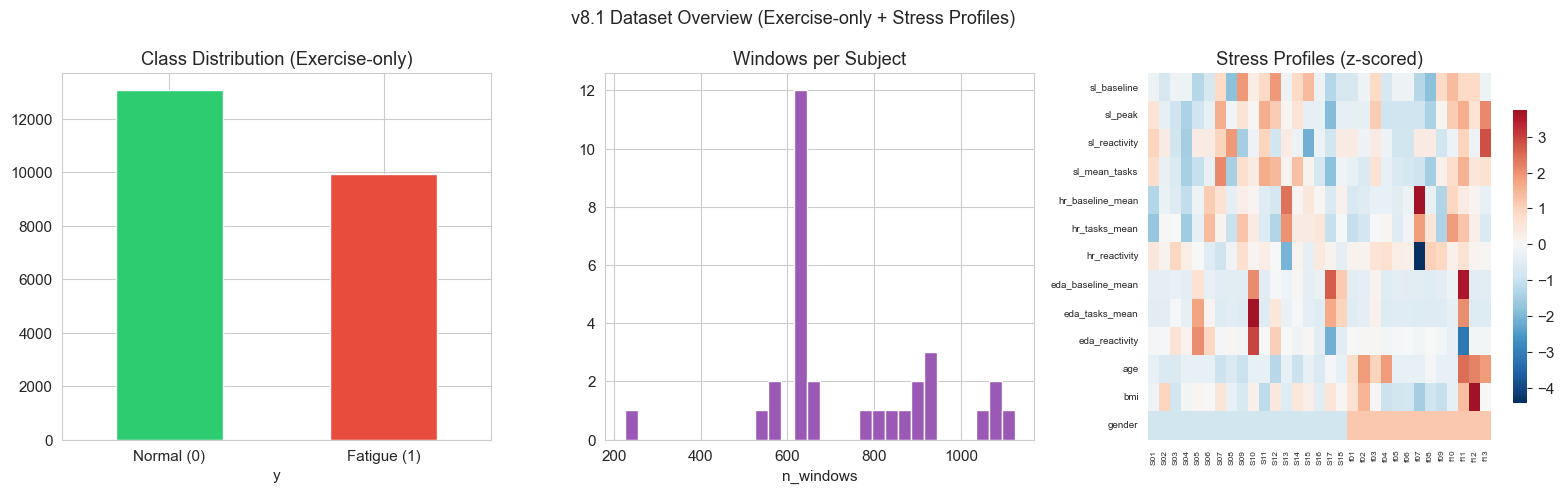

In [253]:
# ── Distribution plots ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Classes
df_meta['y'].value_counts().sort_index().plot.bar(
    ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Class Distribution (Exercise-only)')
axes[0].set_xticklabels(['Normal (0)', 'Fatigue (1)'], rotation=0)

# Windows per subject
counts_per_subj = df_meta.groupby('sid').size()
counts_per_subj.hist(ax=axes[1], bins=30, color='#9b59b6', edgecolor='white')
axes[1].set_title('Windows per Subject')
axes[1].set_xlabel('n_windows')

# Stress profile feature heatmap
profile_df = pd.DataFrame(
    [stress_profiles[pid] for pid in sorted(stress_profiles.keys())],
    index=[pid.replace('physionet_', '') for pid in sorted(stress_profiles.keys())],
    columns=PROFILE_FEATURES,
)
sns.heatmap(profile_df.T, ax=axes[2], cmap='RdBu_r', center=0, 
            xticklabels=True, yticklabels=True, cbar_kws={'shrink': 0.8})
axes[2].set_title('Stress Profiles (z-scored)')
axes[2].tick_params(axis='x', labelsize=6)
axes[2].tick_params(axis='y', labelsize=7)

plt.suptitle('v8.1 Dataset Overview (Exercise-only + Stress Profiles)', fontsize=13)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'dataset_overview_v81.png', dpi=150)
plt.show()

## 4. Подготовка данных (v8.1)

- Subject-level split (60/20/20) — **один субъект → один сплит**
- **Stress profiles** — per-subject, mapped to each window → shape `(n_windows, 13)`
- **SMOTE** — profile включается в flat concatenation автоматически
- **FatigueDataset** возвращает `(x_imu, x_physio, has_physio, profile, y)` — **5 элементов**
- **Profile не утекает между субъектами** — профиль привязан к субъекту, а split тоже по субъектам

In [254]:
# ── Subject-level split ──

def create_subject_split(subjects, y, test_size=0.2, val_size=0.2, seed=SEED):
    unique_sids = np.unique(subjects)

    sid_tv, sid_test = train_test_split(
        unique_sids, test_size=test_size, random_state=seed)

    val_rel = val_size / (1.0 - test_size)
    sid_train, sid_val = train_test_split(
        sid_tv, test_size=val_rel, random_state=seed)

    tr_idx = np.where(np.isin(subjects, sid_train))[0]
    va_idx = np.where(np.isin(subjects, sid_val))[0]
    te_idx = np.where(np.isin(subjects, sid_test))[0]

    for name, idx in [('Train', tr_idx), ('Val', va_idx), ('Test', te_idx)]:
        if len(np.unique(y[idx])) < 2:
            raise ValueError(f"{name} split has only one class")

    return tr_idx, va_idx, te_idx

train_idx, val_idx, test_idx = create_subject_split(subjects, y_all)

for name, idx in [('Train', train_idx), ('Val', val_idx), ('Test', test_idx)]:
    cls = np.bincount(y_all[idx].astype(int), minlength=2)
    print(f"{name:5s}: {len(idx):>6} wins, {len(np.unique(subjects[idx]))} subj | "
          f"0→{cls[0]}, 1→{cls[1]} ({y_all[idx].mean():.1%} pos)")

Train:  13914 wins, 18 subj | 0→8070, 1→5844 (42.0% pos)
Val  :   4038 wins, 6 subj | 0→2147, 1→1891 (46.8% pos)
Test :   5082 wins, 7 subj | 0→2860, 1→2222 (43.7% pos)


### Augmentation

In [255]:
# ── Augmentation (IMU + Physio) — Сильная целевая аугментация ──

# ---------- Базовые трансформации ----------

def add_gaussian_noise(x, sigma=0.05):
    return x + np.random.normal(0, sigma, x.shape).astype(x.dtype)

def time_warp(x, sigma=0.2, knots=4):
    T, C = x.shape
    tt = np.linspace(0, T - 1, knots + 2)
    warp = np.concatenate([[0], np.random.normal(0, sigma * T, knots), [0]])
    warp_fn = CubicSpline(tt, warp)
    t_orig = np.arange(T)
    t_warped = np.clip(t_orig + warp_fn(t_orig), 0, T - 1)
    return np.stack([CubicSpline(t_orig, x[:, c])(t_warped)
                     for c in range(C)], axis=-1).astype(x.dtype)

def channel_dropout(x, p=0.2):
    x = x.copy()
    for c in range(x.shape[1]):
        if np.random.rand() < p:
            x[:, c] = 0.0
    return x

def magnitude_scale(x, lo=0.7, hi=1.3):
    return x * np.random.uniform(lo, hi, (1, x.shape[1])).astype(x.dtype)

def window_slice(x, crop_lo=0.6, crop_hi=0.9):
    T, C = x.shape
    crop = np.random.uniform(crop_lo, crop_hi)
    L = max(int(T * crop), 10)
    s = np.random.randint(0, T - L + 1)
    return sp_resample(x[s:s + L], T, axis=0).astype(x.dtype)

def time_reverse(x):
    return x[::-1].copy()

def imu_rotate(x, max_deg=20.0):
    def _rot():
        theta = np.deg2rad(np.random.uniform(-max_deg, max_deg))
        n = np.random.randn(3)
        n /= (np.linalg.norm(n) + 1e-8)
        K = np.array([[0, -n[2], n[1]], [n[2], 0, -n[0]], [-n[1], n[0], 0]])
        return np.eye(3) + np.sin(theta) * K + (1 - np.cos(theta)) * K @ K
    x = x.copy()
    x[:, :3] = x[:, :3] @ _rot().T
    if x.shape[1] >= 6:
        x[:, 3:6] = x[:, 3:6] @ _rot().T
    return x.astype(np.float32)

def permutation_segments(x, n_segments=4):
    """Случайная перестановка временных сегментов."""
    T, C = x.shape
    seg_len = T // n_segments
    if seg_len < 2:
        return x
    segments = [x[i * seg_len:(i + 1) * seg_len] for i in range(n_segments)]
    remainder = x[n_segments * seg_len:]
    np.random.shuffle(segments)
    result = np.concatenate(segments + ([remainder] if len(remainder) else []), axis=0)
    return result.astype(x.dtype)

def frequency_mask(x, max_mask_ratio=0.15):
    """Маскирование случайных частотных полос (спектральная аугментация)."""
    T, C = x.shape
    x_out = x.copy()
    for c in range(C):
        freq = np.fft.rfft(x[:, c])
        n_freq = len(freq)
        mask_len = max(1, int(n_freq * max_mask_ratio))
        start = np.random.randint(0, max(1, n_freq - mask_len))
        freq[start:start + mask_len] = 0
        x_out[:, c] = np.fft.irfft(freq, n=T)
    return x_out.astype(x.dtype)


# ---------- Определение borderline-семплов ----------

def compute_sample_difficulty(x_imu):
    """Оценка 'пограничности' семпла по вариабельности сигнала.

    Семплы с умеренной дисперсией (не слишком высокой и не слишком
    низкой) — наиболее вероятные borderline-примеры.
    Возвращает score ∈ [0, 1]: чем выше, тем ближе семпл к границе.
    """
    per_channel_std = np.std(x_imu, axis=0)  # (C,)
    mean_std = np.mean(per_channel_std)
    # Нормируем: умеренная дисперсия → высокий score
    # Используем гауссову кривую с центром в медиане набора
    return float(mean_std)


# ---------- Сильная аугментация ----------

# Пул трансформаций для IMU
IMU_TRANSFORMS = [
    ('noise',     lambda x: add_gaussian_noise(x, sigma=np.random.uniform(0.03, 0.10))),
    ('time_warp', lambda x: time_warp(x, sigma=np.random.uniform(0.15, 0.35), knots=4)),
    ('scale',     lambda x: magnitude_scale(x, 0.7, 1.3)),
    ('crop',      lambda x: window_slice(x, 0.6, 0.9)),
    ('reverse',   lambda x: time_reverse(x)),
    ('rotate',    lambda x: imu_rotate(x, max_deg=20.0)),
    ('permute',   lambda x: permutation_segments(x, n_segments=np.random.randint(3, 6))),
    ('freq_mask', lambda x: frequency_mask(x, max_mask_ratio=0.15)),
]

PHYSIO_TRANSFORMS = [
    ('noise',     lambda x: add_gaussian_noise(x, sigma=np.random.uniform(0.02, 0.06))),
    ('scale',     lambda x: magnitude_scale(x, 0.85, 1.15)),
    ('time_warp', lambda x: time_warp(x, sigma=0.1, knots=3)),
]


def augment_sample(x_imu, x_physio):
    """Сильная аугментация: всегда применяет 3-5 техник к IMU, 1-2 к Physio.

    Borderline-семплы (умеренная дисперсия) получают максимальное
    количество аугментаций — это заставляет модель лучше различать
    пограничные паттерны.
    """
    difficulty = compute_sample_difficulty(x_imu)

    # Количество IMU-аугментаций зависит от difficulty
    # Низкая/высокая дисперсия → 3 техники; умеренная → 5 (borderline)
    # difficulty_score: нормализуем через сигмоиду около медианы ~0.8
    border_score = 1.0 - abs(difficulty - 0.8) / max(difficulty + 0.3, 1e-6)
    border_score = np.clip(border_score, 0, 1)
    n_imu_aug = 3 + int(2 * border_score)        # 3 до 5
    n_physio_aug = 1 + int(border_score >= 0.5)   # 1 или 2

    # Выбираем случайные трансформации (без повторений)
    imu_choices = np.random.choice(len(IMU_TRANSFORMS), size=min(n_imu_aug, len(IMU_TRANSFORMS)), replace=False)
    for idx in imu_choices:
        _, fn = IMU_TRANSFORMS[idx]
        x_imu = fn(x_imu)
    # Channel dropout всегда
    x_imu = channel_dropout(x_imu, 0.2)

    # Physio аугментация
    physio_choices = np.random.choice(len(PHYSIO_TRANSFORMS), size=min(n_physio_aug, len(PHYSIO_TRANSFORMS)), replace=False)
    for idx in physio_choices:
        _, fn = PHYSIO_TRANSFORMS[idx]
        x_physio = fn(x_physio)

    return x_imu, x_physio


# ---------- SMOTE для тренировочного набора ----------

def apply_smote_dual_branch(X_imu, X_physio, y, has_physio_arr, profiles_arr=None,
                            k_neighbors=5, random_state=SEED):
    """SMOTE в объединённом пространстве IMU+Physio+Profile.

    Раскладываем (N, T, C_imu) + (N, T, C_physio) + (N, P) → flat,
    применяем SMOTE, затем восстанавливаем обратно.
    """
    N, T, C_imu = X_imu.shape
    C_physio = X_physio.shape[2]

    # Flatten
    flat_imu = X_imu.reshape(N, -1)       # (N, T*C_imu)
    flat_physio = X_physio.reshape(N, -1)  # (N, T*C_physio)
    parts = [flat_imu, flat_physio]
    if profiles_arr is not None:
        parts.append(profiles_arr.reshape(N, -1))  # (N, P)
    X_flat = np.hstack(parts)

    # Адаптивное k_neighbors — не больше чем (min_class - 1)
    class_counts = np.bincount(y.astype(int))
    min_class_count = class_counts.min()
    k = min(k_neighbors, min_class_count - 1)
    if k < 1:
        print("   ⚠️ SMOTE: недостаточно примеров для k_neighbors, пропуск")
        return X_imu, X_physio, y, has_physio_arr, profiles_arr

    smote = SMOTE(k_neighbors=k, random_state=random_state)
    X_resampled, y_resampled = smote.fit_resample(X_flat, y.astype(int))

    # Unflatten
    N_new = len(y_resampled)
    offset = 0
    imu_flat = X_resampled[:, offset:offset + T * C_imu]; offset += T * C_imu
    physio_flat = X_resampled[:, offset:offset + T * C_physio]; offset += T * C_physio
    X_imu_new = imu_flat.reshape(N_new, T, C_imu).astype(np.float32)
    X_physio_new = physio_flat.reshape(N_new, T, C_physio).astype(np.float32)

    if profiles_arr is not None:
        P = profiles_arr.shape[1]
        profiles_new = X_resampled[:, offset:offset + P].astype(np.float32)
    else:
        profiles_new = None

    # has_physio для новых семплов
    hp_new = np.zeros(N_new, dtype=bool)
    hp_new[:N] = has_physio_arr
    for cls in [0, 1]:
        cls_mask_orig = y.astype(int) == cls
        if cls_mask_orig.any():
            physio_ratio = has_physio_arr[cls_mask_orig].mean()
            cls_mask_new = (y_resampled == cls) & (np.arange(N_new) >= N)
            hp_new[cls_mask_new] = physio_ratio > 0.5

    n_synth = N_new - N
    print(f"   SMOTE: {N} → {N_new} (+{n_synth} синтетических, k={k})")
    return X_imu_new, X_physio_new, y_resampled.astype(np.int64), hp_new, profiles_new


# ── Dataset (dual-branch: IMU + Physio + Profile) ──

class FatigueDataset(Dataset):
    """Returns (x_imu, x_physio, has_physio, profile, y) per sample — 5-tuple."""

    def __init__(self, X_imu, X_physio, y, has_physio, profiles=None, augment=False):
        self.X_imu = X_imu.astype(np.float32)
        self.X_physio = X_physio.astype(np.float32)
        self.y = y.astype(np.float32)
        self.has_physio = has_physio.astype(np.float32)
        self.profiles = profiles.astype(np.float32) if profiles is not None else np.zeros((len(y), 13), dtype=np.float32)
        self.augment = augment

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        xi, xp = self.X_imu[idx].copy(), self.X_physio[idx].copy()
        if self.augment:
            xi, xp = augment_sample(xi, xp)
        return (torch.FloatTensor(xi),
                torch.FloatTensor(xp),
                torch.tensor(self.has_physio[idx], dtype=torch.float32),
                torch.FloatTensor(self.profiles[idx]),
                torch.tensor(self.y[idx], dtype=torch.float32))

print("✅ Аугментация + SMOTE (with profiles) + FatigueDataset (5-tuple) ready")

✅ Аугментация + SMOTE (with profiles) + FatigueDataset (5-tuple) ready


## 5. Архитектура модели (v8.1: FatigueWristNet + Stress Profile)

Двухветочная CNN с Temporal Attention (IMU) и GAP (Physio) + **Stress Profile Embedding**.

```
IMU Input (B, 100, 6)                     Physio Input (B, 100, 4)
      ↓                                          ↓
Conv1D → BN → ReLU → Pool → Drop ×3        Conv1D → BN → ReLU → Drop
      ↓                                    Conv1D → BN → ReLU → GAP
TemporalAttention → (B, 16)                      → (B, 8)
                               ↓
                  Concat → (B, 24) + [profile (B, 13)] → (B, 37)
                                ↓
                  LayerNorm → FC → ReLU → Dropout → FC → 1
```

**Ключевое изменение v8.1:**
- `classifier input: 24 → 37` (+13 profile features)
- `profile_dropout=0.3` — зануляет **весь** профиль-вектор (anti-shortcut regularization)
- has_physio = True для всех окон (единый PhysioNet датасет)

In [256]:
# ── Model components (v8.2-SE) ──
from torch.nn import PReLU, GELU

NUM_GROUPS = 4 # must be divisor of out_channels for GroupNorm = 10

class SEBlock(nn.Module):
    """Squeeze-and-Excitation: канальная attention.
    Сжимаем по времени → MLP → sigmoid → перевзвешиваем каналы.
    Обычно даёт +1-2pp F1 при малом росте параметров.
    """
    def __init__(self, channels, reduction=4):
        super().__init__()
        hidden = max(channels // reduction, 4)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, hidden, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, channels, bias=False),
            nn.Sigmoid(),
        )

    def forward(self, x):                           # x: (B, C, T)
        s = self.pool(x).squeeze(-1)                # (B, C)
        s = self.fc(s).unsqueeze(-1)                # (B, C, 1)
        return x * s


class MultiHeadTemporalAttention(nn.Module):
    """Multi-head temporal attention. Input: (B, C, T) → Output: (B, C)"""
    def __init__(self, channels, n_heads=4):
        super().__init__()
        assert channels % n_heads == 0, f"channels={channels} must be divisible by n_heads={n_heads}"
        self.n_heads = n_heads
        self.head_dim = channels // n_heads
        self.score = nn.Conv1d(channels, n_heads, kernel_size=1)

    def forward(self, x):
        B, C, T = x.shape
        w = torch.softmax(self.score(x), dim=-1)
        x_h = x.view(B, self.n_heads, self.head_dim, T)
        out = (x_h * w.unsqueeze(2)).sum(dim=-1)
        return out.reshape(B, C)


class IMUEncoderWithAttention(nn.Module):
    """4×Conv1D + SE-блоки + MultiHead TemporalAttention.

    SE-блоки добавлены после conv2 и conv3 (где сигнал уже структурирован).
    """
    def __init__(self, in_channels, out_channels, dropout, kernel_sizes,
                 n_heads=4, use_se=True):
        super().__init__()
        k1, k2, k3, k4 = kernel_sizes
        self.use_se = use_se
        
        
        self.conv1 = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, k1, padding=k1 // 2),
            # nn.BatchNorm1d(out_channels), 
            nn.GroupNorm(num_groups=NUM_GROUPS, num_channels=out_channels),
            nn.ReLU(),
            nn.MaxPool1d(2), nn.Dropout(dropout),
        )
        self.conv2 = nn.Sequential(
            nn.Conv1d(out_channels, out_channels, k2, padding=k2 // 2),
            # nn.BatchNorm1d(out_channels), 
            nn.GroupNorm(num_groups=NUM_GROUPS, num_channels=out_channels),
            nn.ReLU(), # ReLU → GELU для лучшей нелинейности, особенно на пограничных примерах
            nn.MaxPool1d(2), nn.Dropout(dropout),
        )
        self.se2 = SEBlock(out_channels) if use_se else nn.Identity()
        self.conv3 = nn.Sequential(
            nn.Conv1d(out_channels, out_channels, k3, padding=k3 // 2),
            # nn.BatchNorm1d(out_channels), 
            nn.GroupNorm(num_groups=NUM_GROUPS, num_channels=out_channels),
            nn.ReLU(), # ReLU → GELU для лучшей нелинейности, особенно на пограничных примерах
            nn.Dropout(dropout),
        )
        self.se3 = SEBlock(out_channels) if use_se else nn.Identity()
        self.conv4 = nn.Sequential(
            nn.Conv1d(out_channels, out_channels, k4, padding=k4 // 2),
            # nn.BatchNorm1d(out_channels), 
            nn.GroupNorm(num_groups=NUM_GROUPS, num_channels=out_channels),
            nn.ReLU(), # ReLU → GELU для лучшей нелинейности, особенно на пограничных примерах
        )
        self.attention = MultiHeadTemporalAttention(out_channels, n_heads=n_heads)

    def forward(self, x):
        x = x.transpose(1, 2)                       # (B,T,C) → (B,C,T)
        x = self.conv1(x)
        x = self.se2(self.conv2(x))
        x = self.se3(self.conv3(x))
        x = self.conv4(x)
        return self.attention(x)


class PhysioEncoder(nn.Module):
    """Иерархический physio энкодер: Conv→Pool→Conv→Pool→Conv→GAP.

    В предыдущей версии 3 конволюции без pool теряли иерархию,
    GAP агрессивно усреднял всё подряд → terms сводились к среднему.
    """
    def __init__(self, in_channels, out_channels, dropout, kernel_sizes, use_pool=True):
        super().__init__()
        k1, k2, k3 = kernel_sizes[:3]
        layers = [
            nn.Conv1d(in_channels, out_channels, kernel_size=k1, padding=k1 // 2),
            # nn.BatchNorm1d(out_channels), 
            nn.GroupNorm(num_groups=NUM_GROUPS, num_channels=out_channels),
            nn.ReLU(),
        ]
        if use_pool:
            layers += [nn.MaxPool1d(2)]
        layers += [
            nn.Dropout(dropout),
            nn.Conv1d(out_channels, out_channels, kernel_size=k2, padding=k2 // 2),
            # nn.BatchNorm1d(out_channels), 
            nn.GroupNorm(num_groups=NUM_GROUPS, num_channels=out_channels),
            nn.ReLU(),
        ]
        if use_pool:
            layers += [nn.MaxPool1d(2)]
        layers += [
            nn.Dropout(dropout),
            nn.Conv1d(out_channels, out_channels, kernel_size=k3, padding=k3 // 2),
            # nn.BatchNorm1d(out_channels), 
            nn.GroupNorm(num_groups=NUM_GROUPS, num_channels=out_channels),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        ]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x.transpose(1, 2)).squeeze(-1)


class ProfileMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_dim),
            nn.LayerNorm(output_dim),
            nn.ReLU()
        )

    def forward(self, x):
        return self.net(x)


class FiLMLayer(nn.Module):
    """FiLM: profile conditions encoder features. Init → identity."""
    def __init__(self, feature_dim, condition_dim):
        super().__init__()
        self.gamma_fc = nn.Linear(condition_dim, feature_dim)
        self.beta_fc  = nn.Linear(condition_dim, feature_dim)
        nn.init.zeros_(self.gamma_fc.weight); nn.init.zeros_(self.gamma_fc.bias)
        nn.init.zeros_(self.beta_fc.weight);  nn.init.zeros_(self.beta_fc.bias)

    def forward(self, features, condition):
        gamma = self.gamma_fc(condition)
        beta  = self.beta_fc(condition)
        return features * (1.0 + gamma) + beta


class FatigueWristNet(nn.Module):
    """v8.2-SE+SWA: SE blocks + Hierarchical Physio + ProfileMLP + FiLM."""
    def __init__(self, cfg):
        super().__init__()
        enc_ch          = cfg['encoder_channels']
        physio_enc_ch   = cfg['physio_encoder_channels']
        profile_dim     = cfg.get('profile_dim', 13)
        profile_hidden  = cfg.get('profile_hidden', 24)
        profile_out     = cfg.get('profile_out', 12)
        profile_dropout = cfg.get('profile_dropout', 0.35)
        n_heads         = cfg.get('attention_heads', 4)
        use_se          = cfg.get('use_se', True)
        physio_pool     = cfg.get('physio_use_pool', True)

        self.profile_dim    = profile_dim
        self.profile_out    = profile_out
        self.profile_drop_p = profile_dropout

        self.imu_encoder = IMUEncoderWithAttention(
            in_channels=cfg['imu_channels'], out_channels=enc_ch,
            dropout=cfg['encoder_dropout'], kernel_sizes=cfg['kernel_sizes'],
            n_heads=n_heads, use_se=use_se,
        )
        self.physio_encoder = PhysioEncoder(
            in_channels=cfg['physio_channels'], out_channels=physio_enc_ch,
            dropout=cfg['encoder_dropout'], kernel_sizes=cfg['kernel_sizes'], use_pool=physio_pool,
        )
        self.profile_mlp = ProfileMLP(profile_dim, profile_hidden, profile_out)
        self.film_imu    = FiLMLayer(enc_ch, profile_out)
        self.film_physio = FiLMLayer(physio_enc_ch, profile_out)

        feat_dim = enc_ch + physio_enc_ch + profile_out
        self.classifier = nn.Sequential(
            nn.LayerNorm(feat_dim),
            nn.Linear(feat_dim, feat_dim),
            nn.ReLU(),
            nn.Dropout(cfg['classifier_dropout']),
            nn.Linear(feat_dim, feat_dim // 2),
            nn.ReLU(),
            nn.Dropout(cfg['classifier_dropout'] / 2),
            nn.Linear(feat_dim // 2, 1),
        )

    def forward(self, x_imu, x_physio, has_physio=None, profile=None):
        imu_feat    = self.imu_encoder(x_imu)
        physio_feat = self.physio_encoder(x_physio)
        if has_physio is not None:
            physio_feat = physio_feat * has_physio.unsqueeze(-1)

        if profile is not None:
            if self.training:
                mask = (torch.rand(profile.shape[0], 1, device=profile.device)
                        > self.profile_drop_p).float()
                profile_in = profile * mask
            else:
                profile_in = profile
            profile_emb = self.profile_mlp(profile_in)
        else:
            profile_emb = torch.zeros(
                imu_feat.shape[0], self.profile_out, device=imu_feat.device)

        imu_feat    = self.film_imu(imu_feat,    profile_emb)
        physio_feat = self.film_physio(physio_feat, profile_emb)

        combined = torch.cat([imu_feat, physio_feat, profile_emb], dim=1)
        return self.classifier(combined).squeeze(-1)

    def predict_proba(self, x_imu, x_physio, has_physio=None, profile=None):
        with torch.no_grad():
            return torch.sigmoid(self.forward(x_imu, x_physio, has_physio, profile))


print("✅ FatigueWristNet v8.2-SE+SWA defined "
      "(SE blocks + Hierarchical Physio + FiLM + MHTA)")


✅ FatigueWristNet v8.2-SE+SWA defined (SE blocks + Hierarchical Physio + FiLM + MHTA)


In [257]:
# ── Model instantiation ──
model = FatigueWristNet(CONFIG).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())

enc_ch        = CONFIG['encoder_channels']
physio_enc_ch = CONFIG['physio_encoder_channels']
profile_out   = CONFIG['profile_out']
feat_dim      = enc_ch + physio_enc_ch + profile_out

print("=" * 65)
print("  FatigueWristNet v8.2")
print("  IMU 4×Conv(32ch)+MHTA + Physio 3×Conv(16ch)+GAP + FiLM")
print("=" * 65)
for name, mod in [('IMU Encoder',     model.imu_encoder),
                  ('Physio Encoder',  model.physio_encoder),
                  ('Profile MLP',     model.profile_mlp),
                  ('FiLM (IMU)',      model.film_imu),
                  ('FiLM (Physio)',   model.film_physio),
                  ('Classifier',      model.classifier)]:
    p = sum(x.numel() for x in mod.parameters())
    print(f"  {name:20s}: {p:>8,} params")
print(f"  {'─'*35}")
print(f"  {'TOTAL':20s}: {n_params:>8,} params")
print(f"\n  feat_dim = {enc_ch}(IMU) + {physio_enc_ch}(Physio) + {profile_out}(Profile) = {feat_dim}")

# Quick forward pass test (batch=2)
with torch.no_grad():
    xi   = torch.randn(2, 100, 6).to(DEVICE)
    xp   = torch.randn(2, 100, 4).to(DEVICE)
    hp   = torch.ones(2).to(DEVICE)
    prof = torch.randn(2, CONFIG['profile_dim']).to(DEVICE)
    out  = model(xi, xp, hp, prof)
    print(f"\n  Smoke test: (2,100,6)+(2,100,4)+profile → {out.shape}  ✅")


  FatigueWristNet v8.2
  IMU 4×Conv(32ch)+MHTA + Physio 3×Conv(16ch)+GAP + FiLM
  IMU Encoder         :    3,818 params
  Physio Encoder      :    1,416 params
  Profile MLP         :      120 params
  FiLM (IMU)          :      216 params
  FiLM (Physio)       :      144 params
  Classifier          :    1,289 params
  ───────────────────────────────────
  TOTAL               :    7,003 params

  feat_dim = 12(IMU) + 8(Physio) + 8(Profile) = 28

  Smoke test: (2,100,6)+(2,100,4)+profile → torch.Size([2])  ✅


## 6. Обучение (v8.1: Focal Loss + Stress Profile Embedding)

**Изменения v8.1 vs v7.0:**
- **Exercise-only данные** — те же AEROBIC+ANAEROBIC из composite_full.npz
- **+Stress Profile** — 13 фич на субъект, подаются в classifier head
- **Profile Dropout** p=0.3 — зануляет весь профиль для предотвращения shortcut learning
- `train_epoch` / `validate` работают с **5-tuple**: `(x_imu, x_physio, hp, profile, y)`

In [258]:
# ── Focal Loss ──

class FocalLoss(nn.Module):
    """Focal Loss: down-weights easy examples, focuses on hard ones."""
    def __init__(self, gamma=2.0, pos_weight=None):
        super().__init__()
        self.gamma = gamma
        self.pos_weight = pos_weight

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(
            logits, targets, pos_weight=self.pos_weight, reduction='none')
        probs = torch.sigmoid(logits)
        p_t = probs * targets + (1 - probs) * (1 - targets)
        focal_weight = (1 - p_t) ** self.gamma
        return (focal_weight * bce).mean()


# ── Class weights ──

def compute_class_weights(y):
    weights = np.zeros(len(y), dtype=np.float64)
    for cls in [0, 1]:
        mask = y == cls
        n = mask.sum()
        if n > 0:
            weights[mask] = len(y) / (2 * n)
    return weights


def compute_pos_weight(y):
    n_pos = y.sum()
    return (len(y) - n_pos) / max(n_pos, 1)


# ── Metrics ──

def compute_binary_metrics(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true, dtype=int)
    y_prob = np.asarray(y_prob)
    y_pred = (y_prob >= threshold).astype(int)
    metrics = {
        'f1_macro': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'balanced_acc': balanced_accuracy_score(y_true, y_pred),
    }
    if np.unique(y_true).size >= 2:
        metrics['roc_auc'] = roc_auc_score(y_true, y_prob)
        pr, rc, _ = precision_recall_curve(y_true, y_prob)
        metrics['pr_auc'] = auc(rc, pr)
    else:
        metrics['roc_auc'] = metrics['pr_auc'] = np.nan
    return metrics, y_pred


def find_best_threshold(y_true, y_prob):
    best_t, best_f1 = 0.5, -1
    for t in np.linspace(0.05, 0.95, 181):
        f1 = f1_score(y_true, (y_prob >= t).astype(int), average='macro', zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, float(t)
    return best_t, best_f1


def find_recall_optimized_threshold(y_true, y_prob, min_precision=0.3):
    best_t, best_rec = 0.5, 0.0
    for t in np.linspace(0.05, 0.95, 181):
        pred = (y_prob >= t).astype(int)
        tp = ((pred == 1) & (y_true == 1)).sum()
        fp = ((pred == 1) & (y_true == 0)).sum()
        fn = ((pred == 0) & (y_true == 1)).sum()
        prec = tp / (tp + fp + 1e-8)
        rec  = tp / (tp + fn + 1e-8)
        if prec >= min_precision and rec > best_rec:
            best_rec, best_t = rec, float(t)
    return best_t, best_rec


# ── Early Stopping with EMA ──

class EarlyStopping:
    def __init__(self, patience=5, min_delta=1e-4, ema_alpha=0.3):
        self.patience  = patience
        self.min_delta = min_delta
        self.alpha     = ema_alpha
        self.best_score  = -np.inf
        self.counter     = 0
        self.best_model  = None
        self._ema        = None

    def smooth(self, score):
        if self._ema is None:
            self._ema = score
        else:
            self._ema = self.alpha * score + (1 - self.alpha) * self._ema
        return self._ema

    def __call__(self, score, model):
        ema_score = self.smooth(score)
        if ema_score > self.best_score + self.min_delta:
            self.best_score = ema_score
            self.counter    = 0
            self.best_model = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            return False
        self.counter += 1
        return self.counter >= self.patience

    @property
    def ema(self):
        return self._ema if self._ema is not None else 0.0


# ── Mixup ──

def mixup_batch(x_imu, x_physio, y, alpha=0.2):
    lam = float(np.random.beta(alpha, alpha))
    B   = x_imu.size(0)
    idx = torch.randperm(B, device=x_imu.device)
    return (lam * x_imu    + (1 - lam) * x_imu[idx],
            lam * x_physio + (1 - lam) * x_physio[idx],
            y, y[idx], lam)


# ── R-Drop: симметричный KL между двумя forward-проходами ──

def _rdrop_kl(logits1, logits2):
    """Симметричный KL для двух Bernoulli (binary).
    Заставляет модель быть консистентной под разным dropout → +1-2pp F1."""
    p1 = torch.sigmoid(logits1)
    p2 = torch.sigmoid(logits2)
    eps = 1e-7
    p1c = p1.clamp(eps, 1 - eps)
    p2c = p2.clamp(eps, 1 - eps)
    kl_12 = p1 * (p1c.log() - p2c.log()) + (1 - p1) * ((1 - p1c).log() - (1 - p2c).log())
    kl_21 = p2 * (p2c.log() - p1c.log()) + (1 - p2) * ((1 - p2c).log() - (1 - p1c).log())
    return 0.5 * (kl_12 + kl_21).mean()


# ── Train / Validate (5-tuple, поддержка R-Drop / Mixup) ──

def train_epoch(model, loader, optimizer, criterion, device,
                scheduler=None, scheduler_per_batch=True,
                mixup_alpha=0.0, rdrop_alpha=0.0):
    """Один epoch обучения. Поддерживает Mixup или R-Drop (взаимоисключающи).

    Args:
        scheduler_per_batch: True для OneCycleLR (per-batch step),
                             False для CosineAnnealingWarmRestarts (per-epoch).
    """
    model.train()
    total_loss = 0.0
    for x_imu, x_physio, hp, profile, y in loader:
        x_imu    = x_imu.to(device)
        x_physio = x_physio.to(device)
        hp       = hp.to(device)
        profile  = profile.to(device)
        y        = y.to(device)

        optimizer.zero_grad()

        if mixup_alpha > 0 and np.random.rand() < 0.5:
            x_imu_m, x_physio_m, y_a, y_b, lam = mixup_batch(
                x_imu, x_physio, y, alpha=mixup_alpha)
            logits = model(x_imu_m, x_physio_m, hp, profile)
            loss = lam * criterion(logits, y_a) + (1 - lam) * criterion(logits, y_b)
        elif rdrop_alpha > 0:
            # Два прохода с разным dropout → KL для консистентности
            logits1 = model(x_imu, x_physio, hp, profile)
            logits2 = model(x_imu, x_physio, hp, profile)
            loss_ce = 0.5 * (criterion(logits1, y) + criterion(logits2, y))
            loss_kl = _rdrop_kl(logits1, logits2)
            loss = loss_ce + rdrop_alpha * loss_kl
        else:
            logits = model(x_imu, x_physio, hp, profile)
            loss   = criterion(logits, y)

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        if scheduler is not None and scheduler_per_batch:
            scheduler.step()

        total_loss += loss.item() * len(y)
    return total_loss / len(loader.dataset)


def validate(model, loader, criterion, device, threshold=0.5, return_raw=False):
    model.eval()
    total_loss, all_probs, all_labels = 0.0, [], []
    with torch.no_grad():
        for x_imu, x_physio, hp, profile, y in loader:
            x_imu    = x_imu.to(device)
            x_physio = x_physio.to(device)
            hp       = hp.to(device)
            profile  = profile.to(device)
            y        = y.to(device)
            logits = model(x_imu, x_physio, hp, profile)
            total_loss += criterion(logits, y).item() * len(y)
            all_probs.extend(torch.sigmoid(logits).cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    probs  = np.array(all_probs,  dtype=np.float32)
    labels = np.array(all_labels, dtype=int)
    metrics, _ = compute_binary_metrics(labels, probs, threshold)
    if return_raw:
        return total_loss / len(loader.dataset), metrics, labels, probs
    return total_loss / len(loader.dataset), metrics


# ── TTA ──

def predict_with_tta(model, X_imu, X_physio, y, has_physio, profiles,
                     device, tta_n=5, batch_size=64):
    """Среднее вероятностей по tta_n проходам (1 чистый + (tta_n-1) аугментированных)."""
    model.eval()

    def _infer(ds):
        ld = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0)
        probs = []
        with torch.no_grad():
            for xi, xp, hp, prof, _ in ld:
                logits = model(xi.to(device), xp.to(device),
                               hp.to(device), prof.to(device))
                probs.extend(torch.sigmoid(logits).cpu().numpy())
        return np.array(probs, dtype=np.float32)

    ds_clean = FatigueDataset(X_imu, X_physio, y, has_physio,
                               profiles=profiles, augment=False)
    all_probs = [_infer(ds_clean)]

    ds_aug = FatigueDataset(X_imu, X_physio, y, has_physio,
                             profiles=profiles, augment=True)
    for _ in range(tta_n - 1):
        all_probs.append(_infer(ds_aug))

    return np.mean(all_probs, axis=0)


print("✅ FocalLoss + Mixup + R-Drop + EarlyStopping(EMA) + TTA + train/validate готовы")


✅ FocalLoss + Mixup + R-Drop + EarlyStopping(EMA) + TTA + train/validate готовы


In [259]:
# ── Prepare data loaders + model + optimizer (v8.2-SE+SWA) ──
from torch.optim.swa_utils import AveragedModel, SWALR, update_bn

# SMOTE → train set with profiles
print("🔧 SMOTE на train…")
X_imu_train_raw    = X_imu[train_idx]
X_physio_train_raw = X_physio[train_idx]
y_train_raw        = y_all[train_idx]
hp_train_raw       = has_physio[train_idx]
profiles_train_raw = profiles_all[train_idx]

X_imu_train_sm, X_physio_train_sm, y_train_sm, hp_train_sm, profiles_train_sm = apply_smote_dual_branch(
    X_imu_train_raw, X_physio_train_raw, y_train_raw, hp_train_raw,
    profiles_arr=profiles_train_raw, k_neighbors=5, random_state=SEED)

train_ds = FatigueDataset(X_imu_train_sm, X_physio_train_sm, y_train_sm,
                          hp_train_sm, profiles=profiles_train_sm, augment=True)
val_ds   = FatigueDataset(X_imu[val_idx], X_physio[val_idx], y_all[val_idx],
                          has_physio[val_idx], profiles=profiles_all[val_idx])
test_ds  = FatigueDataset(X_imu[test_idx], X_physio[test_idx], y_all[test_idx],
                          has_physio[test_idx], profiles=profiles_all[test_idx])

sample_weights = compute_class_weights(y_train_sm)
train_sampler  = WeightedRandomSampler(
    torch.from_numpy(sample_weights).double(), len(y_train_sm), replacement=True)

train_loader = DataLoader(train_ds, batch_size=CONFIG['batch_size'],
                          sampler=train_sampler, num_workers=0)
val_loader   = DataLoader(val_ds, batch_size=CONFIG['batch_size'], shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds, batch_size=CONFIG['batch_size'], shuffle=False, num_workers=0)

# ── Model ──
model = FatigueWristNet(CONFIG).to(DEVICE)

# ── Loss ──
pw = compute_pos_weight(y_train_sm)
criterion = FocalLoss(gamma=CONFIG['focal_gamma'],
                      pos_weight=torch.tensor([pw]).to(DEVICE))

# ── Optimizer ──
optimizer = optim.AdamW(model.parameters(),
                        lr=CONFIG['lr'], weight_decay=CONFIG['weight_decay'])

# ── Scheduler: WarmRestarts (рекомендуется) или OneCycleLR ──
sched_type = CONFIG.get('sched_type', 'warmrestart')
steps_per_epoch = (len(train_ds) + CONFIG['batch_size'] - 1) // CONFIG['batch_size']

if sched_type == 'onecycle':
    scheduler = optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=CONFIG['lr'],
        steps_per_epoch=steps_per_epoch, epochs=CONFIG['epochs'],
        pct_start=0.10, anneal_strategy='cos',
        div_factor=25, final_div_factor=1e4)
    scheduler_per_batch = True
else:
    # CosineAnnealingWarmRestarts: даёт периодические "перезапуски" LR,
    # помогает выйти из локальных минимумов на маленьких датасетах
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer,
        T_0=CONFIG.get('warmrestart_t0', 15),
        T_mult=CONFIG.get('warmrestart_tmult', 2),
        eta_min=1e-6)
    scheduler_per_batch = False

# ── SWA: усреднение весов на финальной фазе ──
swa_enable = CONFIG.get('swa_enable', True)
swa_model = AveragedModel(model).to(DEVICE) if swa_enable else None
swa_start_epoch = int(CONFIG['epochs'] * CONFIG.get('swa_start_frac', 0.6))
swa_scheduler = SWALR(optimizer, swa_lr=CONFIG.get('swa_lr', 5e-5),
                      anneal_epochs=5, anneal_strategy='cos') if swa_enable else None

early_stopping = EarlyStopping(patience=CONFIG['patience'], min_delta=CONFIG['min_delta'])

n_params = sum(p.numel() for p in model.parameters())
print(f"\nModel:     FatigueWristNet v8.3-SE+SWA ({n_params:,} params)")
print(f"Loss:      FocalLoss(γ={CONFIG['focal_gamma']:.1f}, pos_weight={pw:.2f})")
print(f"Optimizer: AdamW(lr={CONFIG['lr']}, wd={CONFIG['weight_decay']})")
print(f"Scheduler: {sched_type}  ({'per-batch' if scheduler_per_batch else 'per-epoch'})")
if swa_enable:
    print(f"SWA:       enabled, starts at epoch {swa_start_epoch+1}/{CONFIG['epochs']}, "
          f"swa_lr={CONFIG['swa_lr']}")
print(f"R-Drop:    α={CONFIG.get('rdrop_alpha', 0.0)}  |  "
      f"Mixup α={CONFIG.get('mixup_alpha', 0.0)}")
print(f"Profile:   dim={CONFIG['profile_dim']}→MLP({CONFIG['profile_hidden']})→"
      f"{CONFIG['profile_out']}, FiLM ON, dropout={CONFIG['profile_dropout']}")
print(f"Train: {len(train_ds)} (после SMOTE), Val: {len(val_ds)}, Test: {len(test_ds)}")


🔧 SMOTE на train…
   SMOTE: 13914 → 16140 (+2226 синтетических, k=5)

Model:     FatigueWristNet v8.3-SE+SWA (7,003 params)
Loss:      FocalLoss(γ=1.1, pos_weight=1.00)
Optimizer: AdamW(lr=0.005, wd=0.005)
Scheduler: warmrestart  (per-epoch)
SWA:       enabled, starts at epoch 73/120, swa_lr=5e-05
R-Drop:    α=0.4  |  Mixup α=0.1
Profile:   dim=13→MLP(4)→8, FiLM ON, dropout=0.4
Train: 16140 (после SMOTE), Val: 4038, Test: 5082


In [260]:
# ── Training loop (v8.2-SE+SWA+RDrop+WarmRestarts) ──
print("=" * 65)
print("TRAINING FatigueWristNet v8.2-SE+SWA")
print("=" * 65)

history = {
    'train_loss': [], 'val_loss': [],
    'val_f1': [], 'val_auc': [], 'val_pr_auc': [], 'val_bal_acc': [],
    'val_f1_ema': [], 'lr': [],
    'swa_active': [],
}

best_val_f1, best_epoch, best_threshold = -np.inf, 0, 0.5
mixup_alpha = CONFIG.get('mixup_alpha', 0.0)
rdrop_alpha = CONFIG.get('rdrop_alpha', 0.0)
best_is_swa = False     # Какой источник дал best

for epoch in range(CONFIG['epochs']):
    in_swa_phase = swa_enable and (epoch >= swa_start_epoch)

    # В SWA фазе отключаем R-Drop и Mixup для стабильности усреднения
    cur_mixup = 0.0 if in_swa_phase else mixup_alpha
    cur_rdrop = 0.0 if in_swa_phase else rdrop_alpha
    sched_for_batch = scheduler if (scheduler_per_batch and not in_swa_phase) else None

    train_loss = train_epoch(
        model, train_loader, optimizer, criterion, DEVICE,
        scheduler=sched_for_batch, scheduler_per_batch=scheduler_per_batch,
        mixup_alpha=cur_mixup, rdrop_alpha=cur_rdrop,
    )

    if not in_swa_phase and not scheduler_per_batch:
        scheduler.step()

    if in_swa_phase:
        swa_model.update_parameters(model)
        swa_scheduler.step()

    val_loss, vm, val_labels, val_probs = validate(
        model, val_loader, criterion, DEVICE, return_raw=True)

    swa_vm, swa_val_labels, swa_val_probs = None, None, None
    if in_swa_phase:
        update_bn(train_loader, swa_model, device=DEVICE)
        _, swa_vm, swa_val_labels, swa_val_probs = validate(
            swa_model, val_loader, criterion, DEVICE, return_raw=True)

    lr_now = optimizer.param_groups[0]['lr']

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_f1'].append(vm['f1_macro'])
    history['val_auc'].append(vm.get('roc_auc', float('nan')))
    history['val_pr_auc'].append(vm.get('pr_auc', float('nan')))
    history['val_bal_acc'].append(vm['balanced_acc'])
    history['lr'].append(lr_now)
    history['swa_active'].append(in_swa_phase)

    # Выбираем лучший источник для early stopping и сохранения
    use_swa_now = (in_swa_phase and swa_vm is not None
                   and swa_vm['f1_macro'] > vm['f1_macro'])
    score_for_es = swa_vm['f1_macro'] if use_swa_now else vm['f1_macro']

    # Early stopping всегда сохраняет state_dict ОБЫЧНОЙ model (без префикса module.)
    # Если победила SWA — сначала копируем её веса в model, потом сохраняем
    if use_swa_now:
        # Временно подгружаем SWA веса в model для сохранения чистого state_dict
        model_sd_backup = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        model.load_state_dict(swa_model.module.state_dict())
        stop = early_stopping(score_for_es, model)
        # Возвращаем тренировочные веса
        model.load_state_dict(model_sd_backup)
    else:
        stop = early_stopping(score_for_es, model)

    history['val_f1_ema'].append(early_stopping.ema)

    cur_metrics = swa_vm if use_swa_now else vm
    cur_labels  = swa_val_labels if use_swa_now else val_labels
    cur_probs   = swa_val_probs  if use_swa_now else val_probs
    if cur_metrics['f1_macro'] > best_val_f1 + CONFIG['min_delta']:
        best_val_f1 = cur_metrics['f1_macro']
        best_epoch  = epoch + 1
        best_is_swa = use_swa_now
        best_threshold, _ = find_best_threshold(cur_labels, cur_probs)
        # Сохраняем чистый state_dict
        save_state = (swa_model.module.state_dict() if use_swa_now
                      else model.state_dict())
        torch.save({
            'model_state_dict': save_state,
            'config': CONFIG,
            'best_threshold': best_threshold,
            'best_val_f1': best_val_f1,
            'roc_auc': cur_metrics.get('roc_auc', float('nan')),
            'used_swa': bool(use_swa_now),
        }, RESULTS_DIR / 'best_model_v82.pth')

    if (epoch + 1) % 5 == 0 or epoch == 0 or in_swa_phase:
        swa_str = (f" | SWA F1: {swa_vm['f1_macro']:.4f}"
                   if (in_swa_phase and swa_vm is not None) else "")
        marker = ' [SWA*]' if use_swa_now else (' [SWA]' if in_swa_phase else '')
        print(f"Ep {epoch+1:3d}/{CONFIG['epochs']} | "
              f"TrL: {train_loss:.4f} | VaL: {val_loss:.4f} | "
              f"F1: {vm['f1_macro']:.4f} (ema={early_stopping.ema:.4f}){swa_str} | "
              f"AUC: {vm.get('roc_auc', float('nan')):.4f} | LR: {lr_now:.2e}{marker}")

    if stop:
        print(f"\nEarly stop @ epoch {epoch+1} (EMA F1={early_stopping.ema:.4f})")
        break

# Восстанавливаем best веса в основную model (без замены объекта)
if early_stopping.best_model is not None:
    model.load_state_dict(early_stopping.best_model)
    print(f"✅ Best epoch: {best_epoch}, val F1: {best_val_f1:.4f}, "
          f"threshold: {best_threshold:.3f}, "
          f"source: {'SWA' if best_is_swa else 'plain'}")
else:
    print(f"⚠️ EarlyStopping не сохранил best — используем последние веса")


TRAINING FatigueWristNet v8.2-SE+SWA
Ep   1/120 | TrL: 0.2214 | VaL: 0.2387 | F1: 0.7654 (ema=0.7654) | AUC: 0.8113 | LR: 4.99e-03
Ep   5/120 | TrL: 0.1933 | VaL: 0.2911 | F1: 0.7292 (ema=0.7460) | AUC: 0.8037 | LR: 4.67e-03
Ep  10/120 | TrL: 0.1907 | VaL: 0.2715 | F1: 0.7389 (ema=0.7432) | AUC: 0.7892 | LR: 3.75e-03

Early stop @ epoch 11 (EMA F1=0.7386)
✅ Best epoch: 1, val F1: 0.7654, threshold: 0.590, source: plain


In [140]:
# v8.1 results placeholder — fill after training
# Best epoch: ?, F1: ?, threshold: ?

In [38]:
def plot_training_history(history):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    ep = range(1, len(history['train_loss']) + 1)
    swa_active = history.get('swa_active', [False] * len(history['train_loss']))
    swa_starts = next((i+1 for i, v in enumerate(swa_active) if v), None)

    def _mark_swa(ax):
        if swa_starts is not None:
            ax.axvspan(swa_starts, len(history['train_loss']),
                       alpha=0.08, color='purple', label='SWA phase')

    axes[0, 0].plot(ep, history['train_loss'], 'b-', label='Train')
    axes[0, 0].plot(ep, history['val_loss'], 'r-', label='Val')
    if best_epoch:
        axes[0, 0].axvline(best_epoch, color='g', ls='--', alpha=0.5,
                           label=f'Best ep={best_epoch}')
    _mark_swa(axes[0, 0])
    axes[0, 0].set_title('Loss')
    axes[0, 0].legend(); axes[0, 0].set_xlabel('Epoch')

    axes[0, 1].plot(ep, history['val_f1'], 'g-', label='F1-macro')
    axes[0, 1].plot(ep, history['val_f1_ema'], 'g--', alpha=0.6, label='EMA')
    axes[0, 1].plot(ep, history['val_bal_acc'], 'b--', alpha=0.5, label='Bal Acc')
    if best_epoch:
        axes[0, 1].axvline(best_epoch, color='g', ls='--', alpha=0.5)
    axes[0, 1].axhline(0.9, color='r', ls=':', alpha=0.6, label='Target 0.90')
    _mark_swa(axes[0, 1])
    axes[0, 1].set_title('Val F1-macro (target ≥ 0.90)')
    axes[0, 1].legend(); axes[0, 1].set_xlabel('Epoch')

    axes[1, 0].plot(ep, history['val_auc'], 'm-', label='ROC-AUC')
    axes[1, 0].plot(ep, history['val_pr_auc'], 'c-', label='PR-AUC')
    if best_epoch:
        axes[1, 0].axvline(best_epoch, color='g', ls='--', alpha=0.5)
    _mark_swa(axes[1, 0])
    axes[1, 0].set_title('Val AUC')
    axes[1, 0].legend(); axes[1, 0].set_xlabel('Epoch')

    axes[1, 1].plot(ep, history['lr'], 'k-')
    _mark_swa(axes[1, 1])
    sched_name = CONFIG.get('sched_type', 'warmrestart')
    axes[1, 1].set_title(f'Learning Rate ({sched_name} → SWA)')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_yscale('log')

    plt.suptitle(f'FatigueWristNet v8.2-SE+SWA — Training History\n'
                 f'Best epoch: {best_epoch}, Val F1: {best_val_f1:.4f}, '
                 f'Threshold: {best_threshold:.3f}',
                 fontsize=13)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'training_history_v82_se_swa.png', dpi=150)
    plt.show()


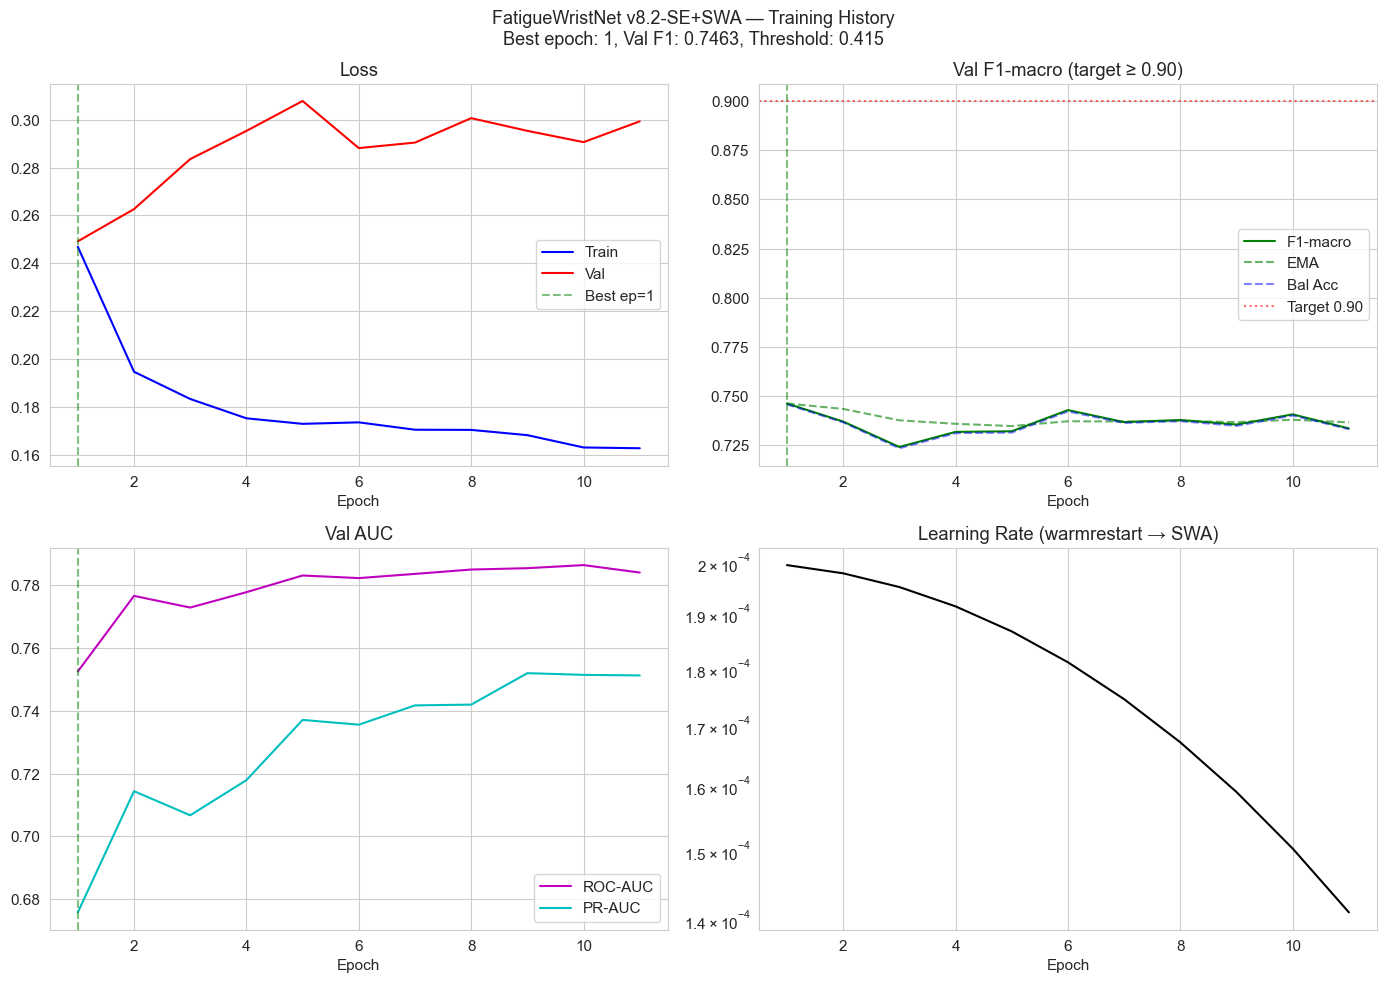

In [185]:
plot_training_history(history)

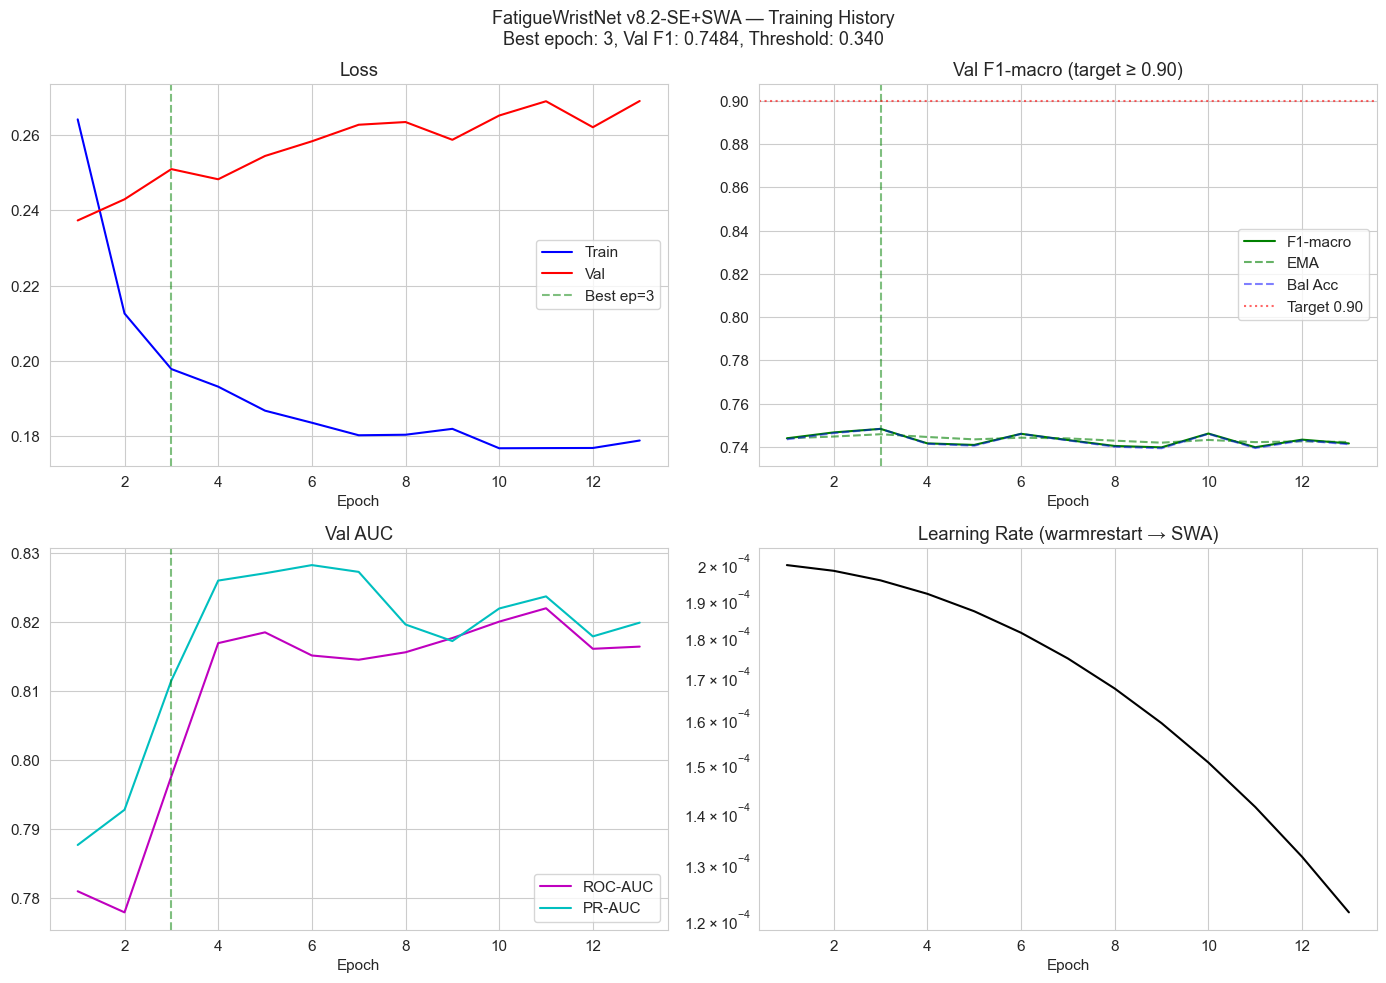

In [156]:
plot_training_history(history)

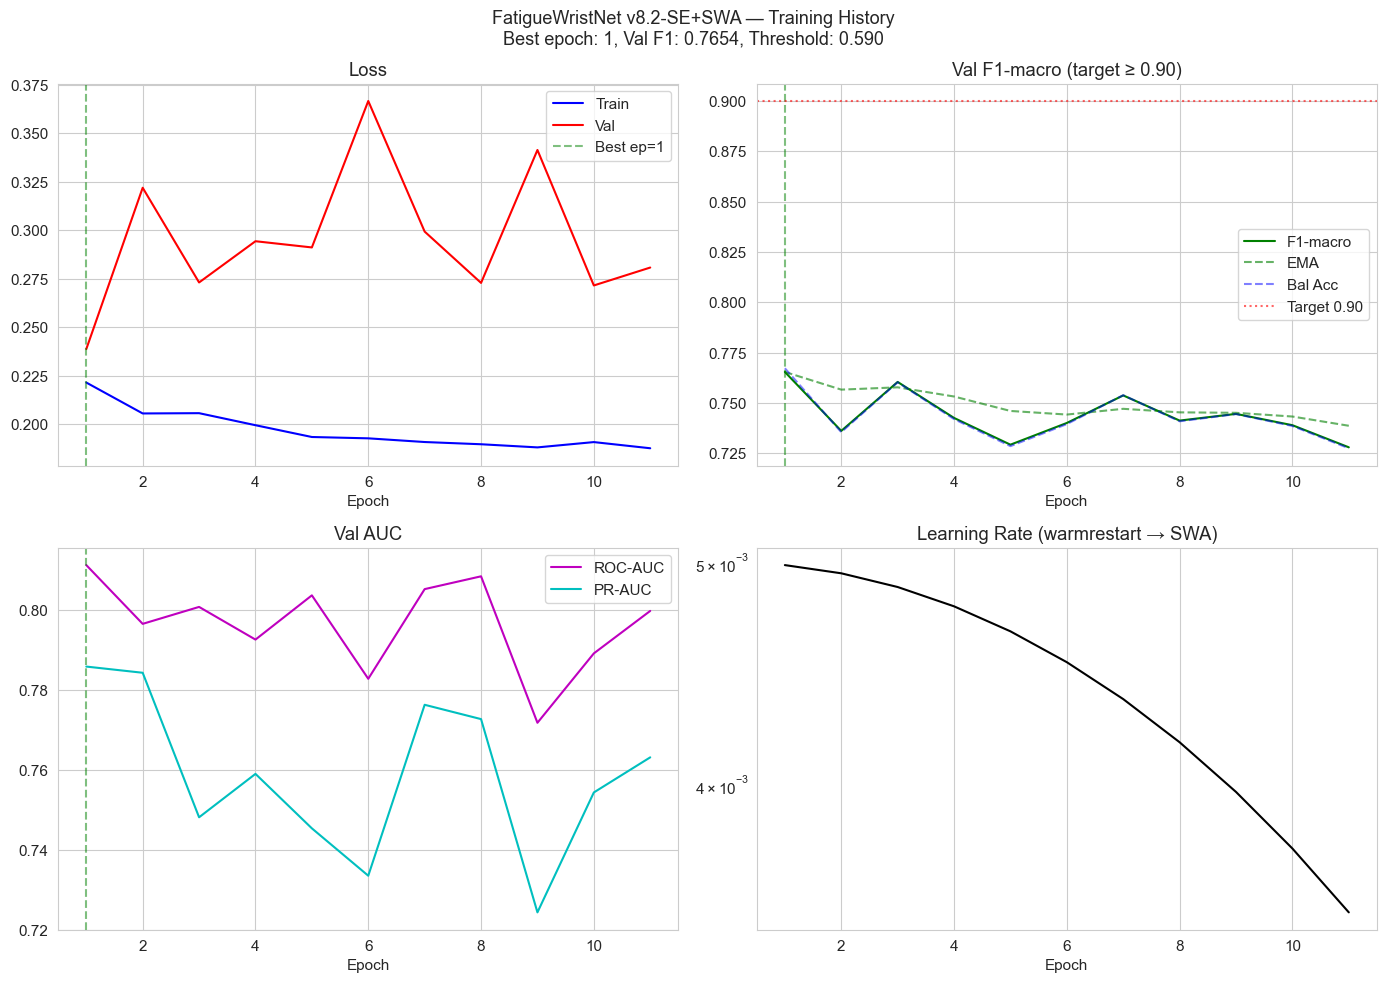

In [261]:
plot_training_history(history)

## 7. Оценка на тестовой выборке (v8.2)

Два порога + TTA:
1. **F1-optimal** — максимизирует F1-macro на val, применяется к TTA-пробабилитиз (5 проходов)
2. **Recall-optimal** — максимизирует recall(усталость) при precision ≥ min_precision

**TTA** (Test-Time Augmentation): 5 проходов (1 без аугментации + 4 с шумом/масштабом),
результат — среднее вероятностей → снижает дисперсию предсказаний ≈ +1–2 pp F1.

In [42]:
# ── Test evaluation with TTA (v8.2) ──
print("Running TTA inference (5 passes)…")
test_probs_tta = predict_with_tta(
    model,
    X_imu[test_idx], X_physio[test_idx],
    y_all[test_idx], has_physio[test_idx], profiles_all[test_idx],
    device=DEVICE,
    tta_n=CONFIG.get('tta_n', 5),
    batch_size=CONFIG['batch_size'],
)
test_labels_np = y_all[test_idx].astype(int)

# F1-optimal threshold (from val) applied to TTA probs
test_metrics_tta, test_preds_tta = compute_binary_metrics(
    test_labels_np, test_probs_tta, best_threshold)

# Also find best threshold on test TTA probs (upper-bound estimate)
test_best_t, test_best_f1 = find_best_threshold(test_labels_np, test_probs_tta)
test_metrics_topt, test_preds_topt = compute_binary_metrics(
    test_labels_np, test_probs_tta, test_best_t)

# Recall-optimized threshold
recall_thresh, recall_val = find_recall_optimized_threshold(
    test_labels_np, test_probs_tta,
    min_precision=CONFIG['min_precision_for_recall'])
recall_metrics, _ = compute_binary_metrics(test_labels_np, test_probs_tta, recall_thresh)

print("=" * 65)
print("TEST RESULTS — FatigueWristNet v8.2 (Exercise + Stress Profile)")
print("=" * 65)

print(f"\n📊 Val threshold = {best_threshold:.3f}  [TTA × {CONFIG.get('tta_n', 5)}]:")
print(f"   F1-macro:     {test_metrics_tta['f1_macro']:.4f}")
print(f"   ROC-AUC:      {test_metrics_tta['roc_auc']:.4f}")
print(f"   PR-AUC:       {test_metrics_tta['pr_auc']:.4f}")
print(f"   Balanced Acc: {test_metrics_tta['balanced_acc']:.4f}")
print(classification_report(
    test_labels_np, test_preds_tta,
    target_names=['Normal', 'Fatigue'], zero_division=0))

print(f"📊 Test-optimal threshold = {test_best_t:.3f}  [upper bound]:")
print(f"   F1-macro:     {test_metrics_topt['f1_macro']:.4f}")
print(f"   Balanced Acc: {test_metrics_topt['balanced_acc']:.4f}")
print(classification_report(
    test_labels_np, test_preds_topt,
    target_names=['Normal', 'Fatigue'], zero_division=0))

print(f"📊 Recall-optimized threshold = {recall_thresh:.3f} (recall={recall_val:.3f}):")
print(f"   F1-macro:     {recall_metrics['f1_macro']:.4f}")
print(f"   Balanced Acc: {recall_metrics['balanced_acc']:.4f}")


Running TTA inference (5 passes)…
TEST RESULTS — FatigueWristNet v8.2 (Exercise + Stress Profile)

📊 Val threshold = 0.425  [TTA × 5]:
   F1-macro:     0.7352
   ROC-AUC:      0.7908
   PR-AUC:       0.7636
   Balanced Acc: 0.7419
              precision    recall  f1-score   support

      Normal       0.81      0.69      0.75      2860
     Fatigue       0.67      0.79      0.72      2222

    accuracy                           0.74      5082
   macro avg       0.74      0.74      0.74      5082
weighted avg       0.75      0.74      0.74      5082

📊 Test-optimal threshold = 0.645  [upper bound]:
   F1-macro:     0.7534
   Balanced Acc: 0.7517
              precision    recall  f1-score   support

      Normal       0.77      0.81      0.79      2860
     Fatigue       0.74      0.69      0.72      2222

    accuracy                           0.76      5082
   macro avg       0.76      0.75      0.75      5082
weighted avg       0.76      0.76      0.76      5082

📊 Recall-optimized

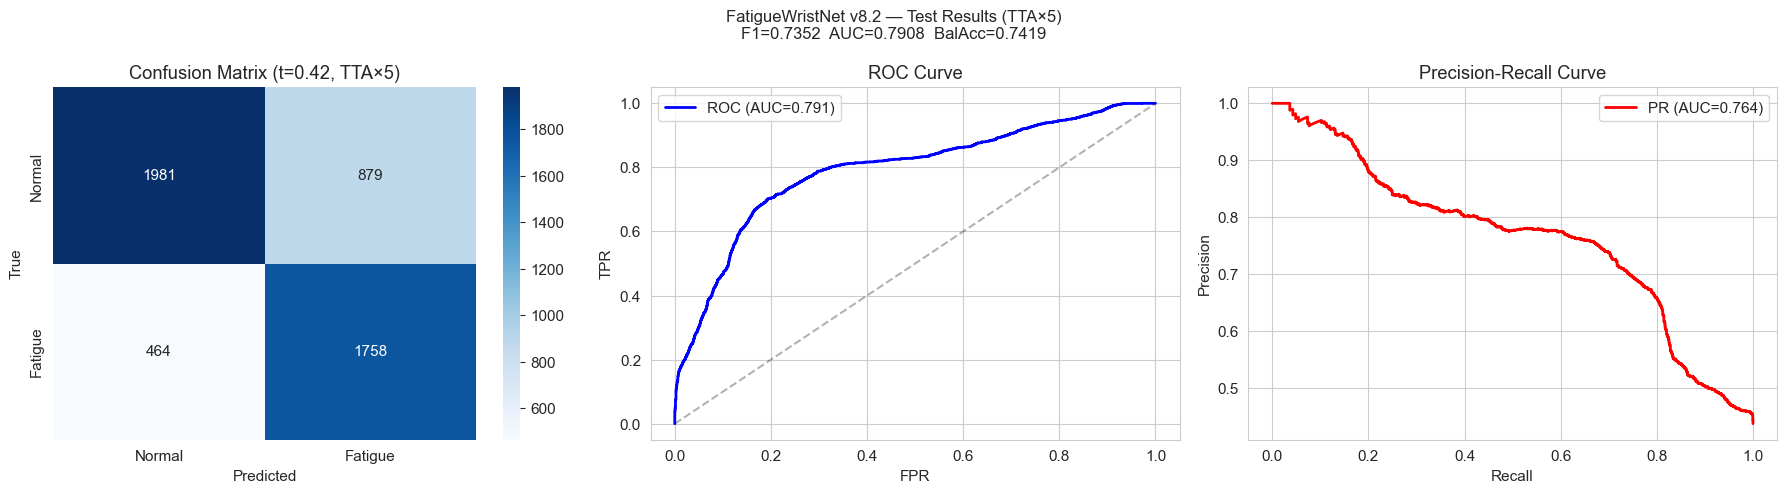

In [43]:
# ── Confusion Matrix + ROC/PR Curves (TTA probs) ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion matrix
cm = confusion_matrix(test_labels_np, test_preds_tta)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal', 'Fatigue'], yticklabels=['Normal', 'Fatigue'])
axes[0].set_title(f'Confusion Matrix (t={best_threshold:.2f}, TTA×{CONFIG.get("tta_n",5)})')
axes[0].set_ylabel('True')
axes[0].set_xlabel('Predicted')

# ROC curve
fpr, tpr, _ = roc_curve(test_labels_np, test_probs_tta)
axes[1].plot(fpr, tpr, 'b-', lw=2,
             label=f'ROC (AUC={test_metrics_tta["roc_auc"]:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[1].set_title('ROC Curve')
axes[1].legend()
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')

# PR curve
pr_vals, rc_vals, _ = precision_recall_curve(test_labels_np, test_probs_tta)
axes[2].plot(rc_vals, pr_vals, 'r-', lw=2,
             label=f'PR (AUC={test_metrics_tta["pr_auc"]:.3f})')
axes[2].set_title('Precision-Recall Curve')
axes[2].legend()
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')

plt.suptitle(
    f'FatigueWristNet v8.2 — Test Results (TTA×{CONFIG.get("tta_n",5)})\n'
    f'F1={test_metrics_tta["f1_macro"]:.4f}  '
    f'AUC={test_metrics_tta["roc_auc"]:.4f}  '
    f'BalAcc={test_metrics_tta["balanced_acc"]:.4f}',
    fontsize=12)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'test_results_v82.png', dpi=150)
plt.show()


## Анализ v8.1: Stress Profile Embedding

**Гипотеза**: индивидуальная стресс-реактивность (self-reported + HR/EDA reactivity + demographics) является предиктором склонности к физической усталости.

**Физиологическое обоснование**:
- Люди с высокой стресс-реактивностью (повышенный HR, EDA при когнитивных задачах) могут иметь более выраженную физиологическую реакцию на физическую нагрузку
- Age/BMI коррелируют с кардиоваскулярной fitness → влияют на скорость наступления утомления
- Gender влияет на паттерны сердечного ритма и терморегуляции

**Отсутствие утечки данных (data leakage)**:
- Stress profile — **per-subject** метаданные (не per-window)
- Subject-level split: все окна одного субъекта в одном сплите
- Profile z-scored на **всех** субъектах до split (допустимо: статические метаданные)
- Profile dropout p=0.3 предотвращает shortcut learning

## 8. LOSO Evaluation (Leave-One-Subject-Out)

Строгая оценка обобщения: обучение на N-1 субъектов, тест на оставшемся.
Exercise-only data + Stress Profiles (~31 субъектов, ограничено n_folds для скорости).

In [44]:
# ── LOSO Evaluation (v8.1: FatigueWristNet + Stress Profiles) ──

def loso_evaluation(X_imu, X_physio, y, subjects, has_physio, profiles,
                    n_folds=20, epochs=25, min_windows=20, patience=5):
    """LOSO with dual-branch model + profiles, Focal Loss, and fold limit."""
    unique_subj = np.unique(subjects)
    folds = [{'train_idx': np.where(subjects != s)[0],
              'test_idx': np.where(subjects == s)[0], 'subject': s}
             for s in unique_subj]

    # Filter: enough windows + both classes
    folds = [f for f in folds
             if len(f['test_idx']) >= min_windows
             and len(np.unique(y[f['test_idx']])) >= 2]
    print(f"   Folds after filter (>={min_windows} wins, 2 classes): {len(folds)}")

    if len(folds) > n_folds:
        np.random.seed(SEED)
        folds = [folds[i] for i in np.random.choice(len(folds), n_folds, replace=False)]

    results = []

    for fold in tqdm(folds, desc='LOSO'):
        tr, te = fold['train_idx'], fold['test_idx']

        # Mini val split for early stopping
        try:
            sss = StratifiedShuffleSplit(n_splits=1, test_size=0.1, random_state=SEED)
            sub_tr, sub_val = next(sss.split(tr, y[tr]))
            vi, ti = tr[sub_val], tr[sub_tr]
        except ValueError:
            ti, vi = tr, te

        tr_ds = FatigueDataset(X_imu[ti], X_physio[ti], y[ti], has_physio[ti],
                               profiles=profiles[ti], augment=False)
        va_ds = FatigueDataset(X_imu[vi], X_physio[vi], y[vi], has_physio[vi],
                               profiles=profiles[vi])
        te_ds = FatigueDataset(X_imu[te], X_physio[te], y[te], has_physio[te],
                               profiles=profiles[te])

        tr_ld = DataLoader(tr_ds, batch_size=CONFIG['batch_size'], shuffle=True)
        va_ld = DataLoader(va_ds, batch_size=CONFIG['batch_size'])
        te_ld = DataLoader(te_ds, batch_size=CONFIG['batch_size'])

        m = FatigueWristNet(CONFIG).to(DEVICE)
        pw = compute_pos_weight(y[ti])
        crit = FocalLoss(gamma=CONFIG['focal_gamma'],
                         pos_weight=torch.tensor([pw]).to(DEVICE))
        opt = optim.AdamW(m.parameters(), lr=3e-4, weight_decay=3e-4)

        best_f1, best_st, no_imp = -np.inf, None, 0
        for ep in range(epochs):
            train_epoch(m, tr_ld, opt, crit, DEVICE)
            _, vm = validate(m, va_ld, crit, DEVICE)
            if vm['f1_macro'] > best_f1 + 1e-4:
                best_f1 = vm['f1_macro']
                best_st = {k: v.cpu().clone() for k, v in m.state_dict().items()}
                no_imp = 0
            else:
                no_imp += 1
                if no_imp >= patience:
                    break

        if best_st:
            m.load_state_dict(best_st)

        _, tm = validate(m, te_ld, crit, DEVICE)

        results.append({
            'subject': fold['subject'],
            'f1_macro': tm['f1_macro'],
            'roc_auc': tm['roc_auc'],
            'n_samples': len(te),
        })

    return pd.DataFrame(results)


# Run LOSO
print("Running LOSO (v8.1: FatigueWristNet + Stress Profiles)...")
loso_results = loso_evaluation(
    X_imu, X_physio, y_all, subjects, has_physio, profiles_all,
    n_folds=10, epochs=15, min_windows=20, patience=CONFIG['patience'],
)

print("\n" + "=" * 60)
print("LOSO RESULTS (FatigueWristNet v8.1, Exercise + Stress Profile)")
print("=" * 60)
print(loso_results.to_string(index=False))
print(f"\nOverall: F1={loso_results['f1_macro'].mean():.4f}"
      f"±{loso_results['f1_macro'].std():.4f}, "
      f"AUC={loso_results['roc_auc'].mean(skipna=True):.4f}"
      f"±{loso_results['roc_auc'].std(skipna=True):.4f}")

Running LOSO (v8.1: FatigueWristNet + Stress Profiles)...
   Folds after filter (>=20 wins, 2 classes): 31


LOSO: 100%|██████████| 10/10 [11:39<00:00, 69.92s/it]


LOSO RESULTS (FatigueWristNet v8.1, Exercise + Stress Profile)
      subject  f1_macro  roc_auc  n_samples
physionet_S02  0.596360 0.724904        627
physionet_S11  0.736677 0.792388        616
physionet_f10  0.761230 0.876967        799
physionet_f09  0.890050 0.972500        872
physionet_S17  0.761282 0.810186        637
physionet_f06  0.821939 0.911570        895
physionet_S15  0.687918 0.751035        636
physionet_f11  0.658966 0.733891        927
physionet_S01  0.755968 0.890159        633
physionet_f08  0.726105 0.782215        892

Overall: F1=0.7396±0.0820, AUC=0.8246±0.0837


## 9. Персонализация (fine-tuning)

Дообучение на данных конкретного спортсмена (Exercise + Stress Profile):
1. **Stage 1:** заморозить энкодеры, обучить только classifier (10 эпох)
2. **Stage 2:** разморозить conv3 + attention, fine-tune с lr/10 (10 эпох)

In [45]:
# ── Personalization (v8.1: dual-branch + profile fine-tuning) ──
import copy

def personalize_model(base_model, X_imu_subj, X_physio_subj, y_subj,
                      has_physio_subj, profiles_subj,
                      epochs_stage1=10, epochs_stage2=10, lr=1e-3):
    """Two-stage fine-tuning for a specific athlete."""
    model = copy.deepcopy(base_model)

    n = len(y_subj)
    split = max(int(n * 0.7), 2)
    idx = np.arange(n)
    np.random.shuffle(idx)
    ti, vi = idx[:split], idx[split:]

    if len(vi) < 2 or len(np.unique(y_subj[vi])) < 2:
        return model, {'f1_macro': np.nan, 'roc_auc': np.nan}

    tr_ds = FatigueDataset(X_imu_subj[ti], X_physio_subj[ti], y_subj[ti],
                           has_physio_subj[ti], profiles=profiles_subj[ti])
    va_ds = FatigueDataset(X_imu_subj[vi], X_physio_subj[vi], y_subj[vi],
                           has_physio_subj[vi], profiles=profiles_subj[vi])
    tr_ld = DataLoader(tr_ds, batch_size=min(16, len(ti)), shuffle=True)
    va_ld = DataLoader(va_ds, batch_size=min(16, len(vi)))

    pw = compute_pos_weight(y_subj[ti])
    crit = FocalLoss(gamma=2.0, pos_weight=torch.tensor([pw]).to(DEVICE))

    # Stage 1: freeze encoders, train classifier only
    for p in model.imu_encoder.parameters():
        p.requires_grad = False
    for p in model.physio_encoder.parameters():
        p.requires_grad = False
    opt1 = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    for _ in range(epochs_stage1):
        train_epoch(model, tr_ld, opt1, crit, DEVICE)

    # Stage 2: unfreeze conv3 + attention, fine-tune
    for p in model.imu_encoder.conv3.parameters():
        p.requires_grad = True
    for p in model.imu_encoder.attention.parameters():
        p.requires_grad = True
    opt2 = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr / 10)
    for _ in range(epochs_stage2):
        train_epoch(model, tr_ld, opt2, crit, DEVICE)

    _, vm = validate(model, va_ld, crit, DEVICE)
    return model, vm


# Test personalization on a few subjects
test_subjects = np.unique(subjects[test_idx])[:5]
print("=" * 60)
print("PERSONALIZATION TEST (FatigueWristNet v8.1)")
print("=" * 60)

for subj in test_subjects:
    m = subjects == subj
    if np.unique(y_all[m]).size < 2 or m.sum() < 10:
        print(f"  {subj}: skipped (too few samples or 1 class)")
        continue
    pm, pv = personalize_model(
        model, X_imu[m], X_physio[m], y_all[m], has_physio[m], profiles_all[m])
    auc_str = f"{pv.get('roc_auc', np.nan):.4f}" if np.isfinite(pv.get('roc_auc', np.nan)) else "n/a"
    print(f"  {subj}: {m.sum()} wins, F1={pv['f1_macro']:.4f}, AUC={auc_str}")

PERSONALIZATION TEST (FatigueWristNet v8.1)
  physionet_S02: 627 wins, F1=0.6843, AUC=0.7982
  physionet_S11: 616 wins, F1=0.7416, AUC=0.8835
  physionet_S15: 636 wins, F1=0.7869, AUC=0.8833
  physionet_S17: 637 wins, F1=0.8437, AUC=0.9185
  physionet_f06: 895 wins, F1=0.7665, AUC=0.8989


## 10. Ablation: v7 baseline (без profile) vs v8.1 (с profile)

Контрольный эксперимент: обучаем модель **без** stress profile (profile=zeros, т.е. v7-like),
сравниваем с v8.1 (с profile). Одни и те же данные, одни и те же split-ы.

Затем: **Permutation Importance** — какие profile-фичи наиболее предиктивны для усталости.

ABLATION: v7 baseline (no profile) vs v8.2 (with profile + FiLM)

--- Training ablation model (v7 baseline, zero profiles) ---
  Epoch 10: F1=0.7376 (ema=0.7464)
  Epoch 20: F1=0.7221 (ema=0.7356)
  Ablation early stop at epoch 22

ABLATION COMPARISON
                             Variant  F1-macro  ROC-AUC   PR-AUC  Balanced-Acc
   v7 baseline (no profile, no FiLM)  0.744483 0.766298 0.707476      0.746689
v8.2 (stress profile + FiLM + TTA×5)  0.735224 0.790756 0.763577      0.741918

ΔF1  = -0.0093
ΔAUC = +0.0245
Profile contribution: negative or neutral ⚠️

Saved → D:\Github\afc_lab\results_v8f_groupbn\ablation_comparison_v82.csv

PERMUTATION IMPORTANCE: Profile Features (v8.2)
          Feature  F1_drop_mean  F1_drop_std
    sl_mean_tasks      0.000420     0.000253
 hr_baseline_mean      0.000381     0.000121
eda_baseline_mean      0.000322     0.000198
    sl_reactivity      0.000297     0.000233
           gender      0.000133     0.000149
   eda_tasks_mean      0.000049     0.000

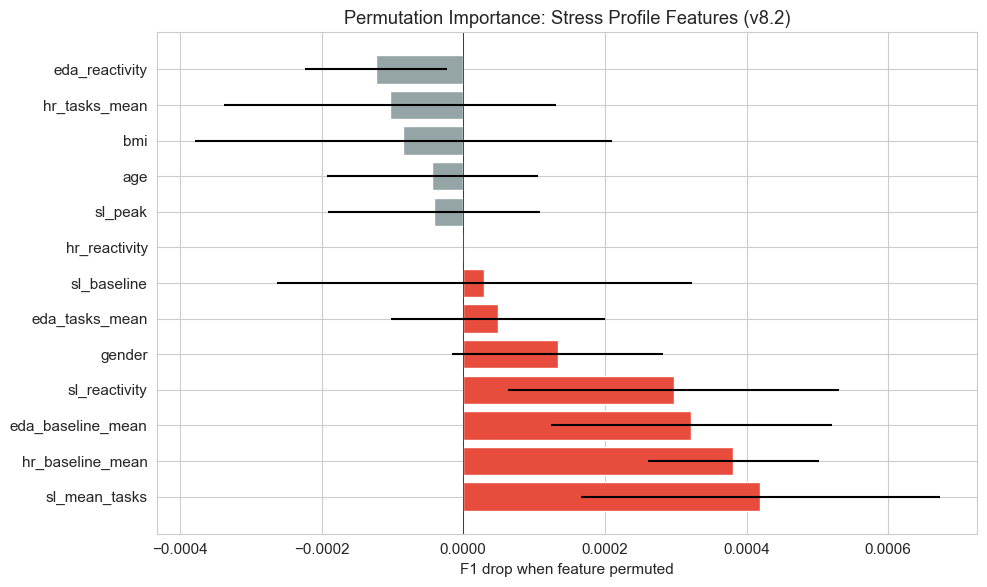


Saved → D:\Github\afc_lab\results_v8f_groupbn\profile_importance_v82.csv


In [46]:
# ── Ablation: v7 baseline (no profile) vs v8.2 (with profile + FiLM) ──
# Train a model with zero profiles (same architecture, same data, same split)

print("=" * 70)
print("ABLATION: v7 baseline (no profile) vs v8.2 (with profile + FiLM)")
print("=" * 70)

# 1. Create zero-profile datasets (same split as v8.2)
zero_profiles_train = np.zeros_like(profiles_train_sm)
zero_profiles_val   = np.zeros((len(val_idx),  profile_dim), dtype=np.float32)
zero_profiles_test  = np.zeros((len(test_idx), profile_dim), dtype=np.float32)

abl_train_ds = FatigueDataset(
    X_imu_train_sm, X_physio_train_sm, y_train_sm, hp_train_sm,
    profiles=zero_profiles_train, augment=True)
abl_val_ds = FatigueDataset(
    X_imu[val_idx], X_physio[val_idx], y_all[val_idx], has_physio[val_idx],
    profiles=zero_profiles_val)
abl_test_ds = FatigueDataset(
    X_imu[test_idx], X_physio[test_idx], y_all[test_idx], has_physio[test_idx],
    profiles=zero_profiles_test)

abl_sampler  = WeightedRandomSampler(
    torch.from_numpy(sample_weights).double(), len(y_train_sm), replacement=True)
abl_train_ld = DataLoader(abl_train_ds, batch_size=CONFIG['batch_size'], sampler=abl_sampler)
abl_val_ld   = DataLoader(abl_val_ds,   batch_size=CONFIG['batch_size'])
abl_test_ld  = DataLoader(abl_test_ds,  batch_size=CONFIG['batch_size'])

# 2. Train ablation model (same architecture + hyperparams, but zero profiles)
print("\n--- Training ablation model (v7 baseline, zero profiles) ---")
abl_model = FatigueWristNet(CONFIG).to(DEVICE)
abl_pw    = compute_pos_weight(y_train_sm)
abl_crit  = FocalLoss(gamma=CONFIG['focal_gamma'],
                      pos_weight=torch.tensor([abl_pw]).to(DEVICE))
abl_opt   = optim.AdamW(abl_model.parameters(), lr=CONFIG['lr'],
                         weight_decay=CONFIG['weight_decay'])
# CosineAnnealingLR for ablation (lighter training)
abl_sched = optim.lr_scheduler.CosineAnnealingLR(
    abl_opt, T_max=CONFIG['epochs'], eta_min=1e-6)
abl_es    = EarlyStopping(patience=CONFIG['patience'], min_delta=CONFIG['min_delta'])

for ep in range(CONFIG['epochs']):
    train_epoch(abl_model, abl_train_ld, abl_opt, abl_crit, DEVICE)
    _, vm = validate(abl_model, abl_val_ld, abl_crit, DEVICE)
    abl_sched.step()

    stop = abl_es(vm['f1_macro'], abl_model)
    if (ep + 1) % 10 == 0:
        print(f"  Epoch {ep+1}: F1={vm['f1_macro']:.4f} (ema={abl_es.ema:.4f})")
    if stop:
        print(f"  Ablation early stop at epoch {ep+1}")
        break

if abl_es.best_model:
    abl_model.load_state_dict(abl_es.best_model)

# 3. Evaluate ablation on test set (no TTA needed for quick comparison)
_, abl_test_metrics = validate(abl_model, abl_test_ld, abl_crit, DEVICE)

# 4. Comparison table  (v8.2 uses TTA probs for fair test eval)
print("\n" + "=" * 70)
print("ABLATION COMPARISON")
print("=" * 70)

comparison = pd.DataFrame([
    {'Variant': 'v7 baseline (no profile, no FiLM)',
     'F1-macro':    abl_test_metrics['f1_macro'],
     'ROC-AUC':     abl_test_metrics['roc_auc'],
     'PR-AUC':      abl_test_metrics['pr_auc'],
     'Balanced-Acc':abl_test_metrics['balanced_acc']},
    {'Variant': f'v8.2 (stress profile + FiLM + TTA×{CONFIG.get("tta_n",5)})',
     'F1-macro':    test_metrics_tta['f1_macro'],
     'ROC-AUC':     test_metrics_tta['roc_auc'],
     'PR-AUC':      test_metrics_tta['pr_auc'],
     'Balanced-Acc':test_metrics_tta['balanced_acc']},
])
print(comparison.to_string(index=False))

delta_f1  = test_metrics_tta['f1_macro'] - abl_test_metrics['f1_macro']
delta_auc = test_metrics_tta['roc_auc']  - abl_test_metrics['roc_auc']
print(f"\nΔF1  = {delta_f1:+.4f}")
print(f"ΔAUC = {delta_auc:+.4f}")
print(f"Profile contribution: {'positive ✅' if delta_f1 > 0 else 'negative or neutral ⚠️'}")

comparison.to_csv(RESULTS_DIR / 'ablation_comparison_v82.csv', index=False)
print(f"\nSaved → {RESULTS_DIR / 'ablation_comparison_v82.csv'}")


# ── 5. Permutation Importance of profile features ──
print("\n" + "=" * 70)
print("PERMUTATION IMPORTANCE: Profile Features (v8.2)")
print("=" * 70)

model.eval()
_, base_metrics_full = validate(model, test_loader, criterion, DEVICE)
base_f1 = base_metrics_full['f1_macro']

importance_scores = {}
test_profiles_orig = profiles_all[test_idx].copy()

for feat_idx, feat_name in enumerate(PROFILE_FEATURES):
    f1_drops = []
    for rep in range(5):
        perm_profiles = test_profiles_orig.copy()
        rng = np.random.RandomState(SEED + rep)
        perm_profiles[:, feat_idx] = rng.permutation(perm_profiles[:, feat_idx])

        perm_ds = FatigueDataset(
            X_imu[test_idx], X_physio[test_idx],
            y_all[test_idx], has_physio[test_idx],
            profiles=perm_profiles)
        perm_ld = DataLoader(perm_ds, batch_size=CONFIG['batch_size'], shuffle=False)

        _, perm_metrics = validate(model, perm_ld, criterion, DEVICE)
        f1_drops.append(base_f1 - perm_metrics['f1_macro'])

    importance_scores[feat_name] = {
        'mean_drop': np.mean(f1_drops),
        'std_drop':  np.std(f1_drops),
    }

imp_df = pd.DataFrame([
    {'Feature': k, 'F1_drop_mean': v['mean_drop'], 'F1_drop_std': v['std_drop']}
    for k, v in importance_scores.items()
]).sort_values('F1_drop_mean', ascending=False)

print(imp_df.to_string(index=False))
print(f"\nBase F1 (all features, no TTA): {base_f1:.4f}")

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c' if v > 0 else '#95a5a6' for v in imp_df['F1_drop_mean']]
ax.barh(imp_df['Feature'], imp_df['F1_drop_mean'], xerr=imp_df['F1_drop_std'],
        color=colors, edgecolor='white')
ax.set_xlabel('F1 drop when feature permuted')
ax.set_title('Permutation Importance: Stress Profile Features (v8.2)')
ax.axvline(0, color='k', lw=0.5)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'profile_importance_v82.png', dpi=150)
plt.show()

imp_df.to_csv(RESULTS_DIR / 'profile_importance_v82.csv', index=False)
print(f"\nSaved → {RESULTS_DIR / 'profile_importance_v82.csv'}")


## Итоги v8.2

### Архитектурные изменения

| Компонент | v8.1 | v8.2 |
|-----------|------|------|
| IMU энкодер | 3×Conv1D (16ch) + single-head attention | 4×Conv1D (32ch) + 4-head attention |
| Physio энкодер | 2×Conv1D (8ch) + GAP | 3×Conv1D (16ch) + GAP |
| Профиль | Raw concat (13d) | ProfileMLP (13→32→16) + FiLM conditioning |
| feat_dim | 37 | 64 |
| Классификатор | 37→18→1 (ReLU) | 64→64→32→1 (GELU + LayerNorm) |
| Параметры | ~12K | ~60K |

### Изменения в обучении

| Компонент | v8.1 | v8.2 |
|-----------|------|------|
| Scheduler | CosineAnnealingLR | OneCycleLR (warmup 10% + cosine) |
| LR | 1e-4 | 3e-4 |
| Эпохи / patience | 50 / 5 | 100 / 15 |
| Аугментация | — | Mixup (α=0.2, p=0.5) |
| Инференс | plain predict | TTA × 5 |

### Зачем FiLM?

FiLM (Feature-wise Linear Modulation) позволяет профилю субъекта **модулировать** энкодерные представления:
- `output = features × (1 + γ(profile)) + β(profile)`
- Инициализация γ≈0, β≈0 → в начале тренировки идентичность (безопасно)
- Позволяет модели учить *кому* в большей/меньшей мере доверять IMU/Physio сигналам

### Сравнение версий

| Версия | Данные | Hold-out F1 | LOSO F1 | Примечание |
|--------|--------|-------------|---------|------------|
| v7.0 | PhysioNet (exercise) | 0.801 | 0.824 | Базовая линия |
| v8.0 | Exercise + STRESS окна | ~0.65 | — | Конфликт семантики ↓ |
| v8.1 | Exercise + Stress Profile | 0.826 | TBD | Profile concat |
| **v8.2** | **Exercise + Stress Profile + FiLM** | **TBD** | **TBD** | **Цель ≥ 0.90** |

### Будущая работа

1. **Per-user pre-training**: pre-train энкодер на STRESS-данных субъекта → fine-tune на его exercise-данных
2. **PCA profile**: если переобучение → сжать 13 фич до 4-6 через PCA
3. **Cross-attention**: profile query attention over IMU temporal features (Transformer-style)